# 260316 LSH New

이번 노트북은 처음부터 다시 시작한다.

현재 단계 목표는 아래 두 데이터를 불러오는 것이다.

- `2024년 데이터`: 학습(`train`)과 검증(`valid`)에 사용할 원본 데이터
- `2025_data.parquet`: 최종 테스트(`test`)에 사용할 원본 데이터


## 데이터 불러오기 계획

먼저 각 파일을 읽고, shape / 컬럼명 / 앞부분 데이터를 확인한다.

이 단계에서는 아직 전처리나 필터링은 하지 않고, 원본이 어떤 구조인지 확인하는 데 집중한다.


In [14]:
import pandas as pd
from pathlib import Path


In [15]:
candidate_2024_paths = [
    Path("Data/정류장정보_시간대별_합친것.csv"),
    Path("../../Data/정류장정보_시간대별_합친것.csv"),
]

candidate_2025_paths = [
    Path("Data/2025_data.parquet"),
    Path("../../Data/2025_data.parquet"),
]

for candidate in candidate_2024_paths:
    if candidate.exists():
        DATA_2024_PATH = candidate
        break
else:
    raise FileNotFoundError("2024년 원본 CSV 파일을 찾지 못했습니다.")

for candidate in candidate_2025_paths:
    if candidate.exists():
        DATA_2025_PATH = candidate
        break
else:
    raise FileNotFoundError("2025_data.parquet 파일을 찾지 못했습니다.")

print(f"2024 데이터 경로: {DATA_2024_PATH}")
print(f"2025 데이터 경로: {DATA_2025_PATH}")


2024 데이터 경로: ../../Data/정류장정보_시간대별_합친것.csv
2025 데이터 경로: ../../Data/2025_data.parquet


In [16]:
df_2024 = pd.read_csv(DATA_2024_PATH)

print("[2024 데이터]")
print(f"shape: {df_2024.shape}")
print("columns:")
print(df_2024.columns.tolist())
display(df_2024.head())


[2024 데이터]
shape: (1997933, 15)
columns:
['기준_날짜', '집계_기준', '기준_시간대', '시작_대여소_ID', '시작_대여소명', '종료_대여소_ID', '종료_대여소명', '전체_건수', '전체_이용_분', '전체_이용_거리', '대여소_ID', '주소1', '주소2', '위도', '경도']


,기준_날짜,집계_기준,기준_시간대,시작_대여소_ID,시작_대여소명,종료_대여소_ID,종료_대여소명,전체_건수,전체_이용_분,전체_이용_거리,대여소_ID,주소1,주소2,위도,경도
0,20240101,출발시간,1735.0,ST-479,역촌동_068_1,ST-462,신사2동_025_1,2.0,151.0,21873.0,ST-479,서울특별시 은평구 역촌동 45-34,역촌파출소,37.604736,126.915337
1,20240101,도착시간,1705.0,ST-455,응암1동_032_1,ST-2779,역촌동_030_1,1.0,3.0,102.0,ST-455,서울특별시 은평구 은평로 85 CJ드림시티,NaN,37.599495,126.916985
2,20240101,도착시간,1705.0,ST-460,응암3동_017_1,ST-2425,신사1동_036_1,1.0,11.0,550.0,ST-460,서울특별시 은평구 응암동 604-5,응암오거리,37.589661,126.916946
3,20240101,도착시간,1705.0,ST-461,응암1동_032_2,ST-2425,신사1동_036_1,1.0,15.0,1582.0,ST-461,서울특별시 은평구 응암동 90-15,이마트 은평점,37.600700,126.920128
4,20240101,도착시간,1705.0,ST-479,역촌동_068_1,ST-479,역촌동_068_1,1.0,22.0,2526.0,ST-479,서울특별시 은평구 역촌동 45-34,역촌파출소,37.604736,126.915337


In [17]:
df_2025 = pd.read_parquet(DATA_2025_PATH)

print("[2025 데이터]")
print(f"shape: {df_2025.shape}")
print("columns:")
print(df_2025.columns.tolist())
display(df_2025.head())


[2025 데이터]
shape: (1853028, 10)
columns:
['기준_날짜', '집계_기준', '기준_시간대', '시작_대여소_ID', '시작_대여소명', '종료_대여소_ID', '종료_대여소명', '전체_건수', '전체_이용_분', '전체_이용_거리']


,기준_날짜,집계_기준,기준_시간대,시작_대여소_ID,시작_대여소명,종료_대여소_ID,종료_대여소명,전체_건수,전체_이용_분,전체_이용_거리
0,20250109,출발시간,900.0,ST-2775,응암1동_032_1,ST-462,응암3동_002_2,1,9,1379
1,20250109,출발시간,1905.0,ST-462,응암3동_002_2,ST-2775,응암1동_032_1,1,10,1368
2,20250109,출발시간,1625.0,ST-2782,갈현1동_002_2,ST-481,구산동_029_1,1,8,1281
3,20250109,출발시간,1450.0,ST-3169,구산동_060_1,ST-1036,역촌동_044_1,1,5,1455
4,20250109,출발시간,1610.0,ST-2261,진관동_106_1,ST-3126,진관동_076_1,1,8,1060


## 다음 단계

이제 다음으로 진행할 작업은 아래 순서가 적절하다.

1. 2024 데이터와 2025 데이터의 컬럼 구조가 같은지 비교
2. 필요한 스테이션만 필터링
3. 날짜/시간 컬럼을 동일한 형식으로 변환
4. 학습/검증/테스트 기준에 맞는 공통 전처리 시작


## 컬럼 구조 비교

먼저 2024 데이터와 2025 데이터의 컬럼 구조가 같은지 확인한다.

같다면 동일한 전처리 파이프라인을 적용할 수 있다.
다르면 어떤 컬럼이 차이나는지 먼저 확인해야 한다.


In [18]:
columns_2024 = df_2024.columns.tolist()
columns_2025 = df_2025.columns.tolist()

same_schema = columns_2024 == columns_2025
common_columns = sorted(set(columns_2024) & set(columns_2025))
only_2024 = sorted(set(columns_2024) - set(columns_2025))
only_2025 = sorted(set(columns_2025) - set(columns_2024))

print(f"컬럼 순서까지 완전히 동일한가: {same_schema}")
print(f"공통 컬럼 수: {len(common_columns)}")
print(f"2024에만 있는 컬럼: {only_2024}")
print(f"2025에만 있는 컬럼: {only_2025}")


컬럼 순서까지 완전히 동일한가: False
공통 컬럼 수: 10
2024에만 있는 컬럼: ['경도', '대여소_ID', '위도', '주소1', '주소2']
2025에만 있는 컬럼: []


## 필요한 스테이션만 필터링

구조 비교 후, 분석에 필요한 시작 스테이션만 남긴다.

이번 분석 대상 스테이션은 다음 3개다.

- `ST-464`
- `ST-481`
- `ST-479`

필터 기준은 `시작_대여소_ID`이다.


In [19]:
TARGET_STATIONS = ["ST-464", "ST-481", "ST-479"]

filtered_2024 = df_2024[df_2024["시작_대여소_ID"].isin(TARGET_STATIONS)].copy()
filtered_2025 = df_2025[df_2025["시작_대여소_ID"].isin(TARGET_STATIONS)].copy()

print("[2024 필터링 결과]")
print(f"shape: {filtered_2024.shape}")
display(filtered_2024["시작_대여소_ID"].value_counts().sort_index())

print("[2025 필터링 결과]")
print(f"shape: {filtered_2025.shape}")
display(filtered_2025["시작_대여소_ID"].value_counts().sort_index())


[2024 필터링 결과]
shape: (140255, 15)


시작_대여소_ID
ST-464    31185
ST-479    65134
ST-481    43936
Name: count, dtype: int64

[2025 필터링 결과]
shape: (115526, 10)


시작_대여소_ID
ST-464    22854
ST-479    58237
ST-481    34435
Name: count, dtype: int64

## 2024 기준 스테이션으로 2025 맞추기

2024 데이터를 기준으로 학습 대상 스테이션 집합을 만들고, 2025 데이터는 이 스테이션 집합에 해당하는 데이터만 남긴다.

즉, `2024에서 본 스테이션만 2025 테스트에도 사용`하는 방식이다.


In [20]:
train_station_ids = sorted(filtered_2024["시작_대여소_ID"].dropna().unique().tolist())
filtered_2025_matched = filtered_2025[filtered_2025["시작_대여소_ID"].isin(train_station_ids)].copy()

print(f"2024 기준 스테이션 수: {len(train_station_ids)}")
print(train_station_ids)
print()
print(f"매칭 후 2025 shape: {filtered_2025_matched.shape}")
display(filtered_2025_matched["시작_대여소_ID"].value_counts().sort_index())


2024 기준 스테이션 수: 3
['ST-464', 'ST-479', 'ST-481']

매칭 후 2025 shape: (115526, 10)


시작_대여소_ID
ST-464    22854
ST-479    58237
ST-481    34435
Name: count, dtype: int64

## 공통 컬럼 기준으로 맞추기

2024와 2025의 구조가 완전히 같지 않더라도, 공통 컬럼만 선택하면 동일한 전처리 파이프라인을 적용할 수 있다.

이 단계에서는 두 데이터에 공통으로 존재하는 컬럼만 남긴다.


In [21]:
common_columns = sorted(set(filtered_2024.columns) & set(filtered_2025_matched.columns))

aligned_2024 = filtered_2024[common_columns].copy()
aligned_2025 = filtered_2025_matched[common_columns].copy()

print(f"공통 컬럼 수: {len(common_columns)}")
print(common_columns)
print()
print(f"aligned_2024 shape: {aligned_2024.shape}")
print(f"aligned_2025 shape: {aligned_2025.shape}")
display(aligned_2024.head())
display(aligned_2025.head())


공통 컬럼 수: 10
['기준_날짜', '기준_시간대', '시작_대여소_ID', '시작_대여소명', '전체_건수', '전체_이용_거리', '전체_이용_분', '종료_대여소_ID', '종료_대여소명', '집계_기준']

aligned_2024 shape: (140255, 10)
aligned_2025 shape: (115526, 10)


,기준_날짜,기준_시간대,시작_대여소_ID,시작_대여소명,전체_건수,전체_이용_거리,전체_이용_분,종료_대여소_ID,종료_대여소명,집계_기준
0,20240101,1735.0,ST-479,역촌동_068_1,2.0,21873.0,151.0,ST-462,신사2동_025_1,출발시간
4,20240101,1705.0,ST-479,역촌동_068_1,1.0,2526.0,22.0,ST-479,역촌동_068_1,도착시간
10,20240101,1710.0,ST-479,역촌동_068_1,1.0,169.0,16.0,ST-479,역촌동_068_1,출발시간
26,20240101,1700.0,ST-464,역촌동_022_1,3.0,8110.0,65.0,ST-463,증산동_004_1,출발시간
64,20240101,1650.0,ST-479,역촌동_068_1,1.0,1390.0,7.0,ST-454,대조동_024_1,도착시간


,기준_날짜,기준_시간대,시작_대여소_ID,시작_대여소명,전체_건수,전체_이용_거리,전체_이용_분,종료_대여소_ID,종료_대여소명,집계_기준
11,20250109,2310.0,ST-464,역촌동_032_1,1,915,5,ST-2775,응암1동_032_1,출발시간
18,20250109,2045.0,ST-481,구산동_029_1,1,1203,9,ST-459,녹번동_043_1,출발시간
35,20250109,2100.0,ST-479,역촌동_080_1,1,1333,9,ST-1331,응암3동_023_1,출발시간
38,20250109,920.0,ST-479,역촌동_080_1,1,1900,8,ST-465,응암1동_059_1,출발시간
42,20250109,815.0,ST-479,역촌동_080_1,1,1400,7,ST-2257,응암3동_002_1,출발시간


## 완전 중복 데이터 점검 및 제거

- 원본 데이터에는 같은 행이 여러 번 저장된 완전 중복이 있을 수 있습니다.
- 이런 경우는 재고 흐름과 수요량을 과대계산할 수 있으므로, 보수적으로 `모든 컬럼이 동일한 행`만 제거합니다.
- 반면 같은 시각/같은 스테이션 이벤트가 여러 건 있는 것은 자연스러울 수 있으므로 이 단계에서는 삭제하지 않습니다.


In [22]:
full_duplicate_count_2024 = aligned_2024.duplicated().sum()
full_duplicate_count_2025 = aligned_2025.duplicated().sum()

deduped_2024 = aligned_2024.drop_duplicates().copy()
deduped_2025 = aligned_2025.drop_duplicates().copy()

print("[완전 중복 점검 결과]")
print(f"2024 완전 중복 행 수: {full_duplicate_count_2024:,}")
print(f"2025 완전 중복 행 수: {full_duplicate_count_2025:,}")
print()
print("[중복 제거 결과]")
print(f"2024 제거 전: {len(aligned_2024):,} / 제거 후: {len(deduped_2024):,} / 제거 행 수: {len(aligned_2024) - len(deduped_2024):,}")
print(f"2025 제거 전: {len(aligned_2025):,} / 제거 후: {len(deduped_2025):,} / 제거 행 수: {len(aligned_2025) - len(deduped_2025):,}")

display(deduped_2024.head())
display(deduped_2025.head())


[완전 중복 점검 결과]
2024 완전 중복 행 수: 861
2025 완전 중복 행 수: 18

[중복 제거 결과]
2024 제거 전: 140,255 / 제거 후: 139,394 / 제거 행 수: 861
2025 제거 전: 115,526 / 제거 후: 115,508 / 제거 행 수: 18


,기준_날짜,기준_시간대,시작_대여소_ID,시작_대여소명,전체_건수,전체_이용_거리,전체_이용_분,종료_대여소_ID,종료_대여소명,집계_기준
0,20240101,1735.0,ST-479,역촌동_068_1,2.0,21873.0,151.0,ST-462,신사2동_025_1,출발시간
4,20240101,1705.0,ST-479,역촌동_068_1,1.0,2526.0,22.0,ST-479,역촌동_068_1,도착시간
10,20240101,1710.0,ST-479,역촌동_068_1,1.0,169.0,16.0,ST-479,역촌동_068_1,출발시간
26,20240101,1700.0,ST-464,역촌동_022_1,3.0,8110.0,65.0,ST-463,증산동_004_1,출발시간
64,20240101,1650.0,ST-479,역촌동_068_1,1.0,1390.0,7.0,ST-454,대조동_024_1,도착시간


,기준_날짜,기준_시간대,시작_대여소_ID,시작_대여소명,전체_건수,전체_이용_거리,전체_이용_분,종료_대여소_ID,종료_대여소명,집계_기준
11,20250109,2310.0,ST-464,역촌동_032_1,1,915,5,ST-2775,응암1동_032_1,출발시간
18,20250109,2045.0,ST-481,구산동_029_1,1,1203,9,ST-459,녹번동_043_1,출발시간
35,20250109,2100.0,ST-479,역촌동_080_1,1,1333,9,ST-1331,응암3동_023_1,출발시간
38,20250109,920.0,ST-479,역촌동_080_1,1,1900,8,ST-465,응암1동_059_1,출발시간
42,20250109,815.0,ST-479,역촌동_080_1,1,1400,7,ST-2257,응암3동_002_1,출발시간


## 이용시간/이용거리 결측 및 이상치 분류

`전체_이용_분`, `전체_이용_거리`는 단순히 0이면 바로 삭제하기보다 먼저 유형을 나눠서 보는 것이 더 타당하다.

가능한 해석은 다음과 같다.

- `정상 이용`: 이용시간 > 0 이고 이용거리 > 0
- `즉시 반납/취소 후보`: 이용시간 = 0 이고 이용거리 = 0
- `시간 정보 이상`: 이용시간 <= 0 또는 결측인데 이용거리는 양수
- `거리 정보 이상`: 이용거리는 <= 0 또는 결측인데 이용시간은 양수
- `완전 결측`: 이용시간, 이용거리 모두 결측

분석 목적이 `수요 예측`이라도, `0분 0거리`는 실제 이동이 아니라 잠금 해제 후 즉시 취소, 오류, 반납 미기록 등 여러 경우가 섞일 수 있다.
따라서 이번에는 보수적으로 `정상 이용`만 남기고 나머지는 제거하는 정제 버전을 만든다.

이 방식의 장점은 다음과 같다.

- 설명이 명확하다.
- 삭제된 데이터 수를 근거로 제시할 수 있다.
- 이후 모델이 이상치에 덜 흔들린다.


In [23]:
def classify_usage_rows(df):
    result = df.copy()
    result["전체_이용_분_num"] = pd.to_numeric(result["전체_이용_분"], errors="coerce")
    result["전체_이용_거리_num"] = pd.to_numeric(result["전체_이용_거리"], errors="coerce")

    duration_missing = result["전체_이용_분_num"].isna()
    distance_missing = result["전체_이용_거리_num"].isna()
    duration_nonpos = result["전체_이용_분_num"].fillna(0) <= 0
    distance_nonpos = result["전체_이용_거리_num"].fillna(0) <= 0
    duration_pos = result["전체_이용_분_num"].fillna(0) > 0
    distance_pos = result["전체_이용_거리_num"].fillna(0) > 0

    result["이용데이터_상태"] = "기타"
    result.loc[duration_pos & distance_pos, "이용데이터_상태"] = "정상 이용"
    result.loc[duration_missing & distance_missing, "이용데이터_상태"] = "완전 결측"
    result.loc[duration_nonpos & distance_nonpos & ~(duration_missing & distance_missing), "이용데이터_상태"] = "즉시 반납/취소 후보"
    result.loc[(duration_missing | duration_nonpos) & distance_pos, "이용데이터_상태"] = "시간 정보 이상"
    result.loc[duration_pos & (distance_missing | distance_nonpos), "이용데이터_상태"] = "거리 정보 이상"

    return result


classified_2024 = classify_usage_rows(deduped_2024)
classified_2025 = classify_usage_rows(deduped_2025)

summary_2024 = classified_2024["이용데이터_상태"].value_counts().rename("2024_count")
summary_2025 = classified_2025["이용데이터_상태"].value_counts().rename("2025_count")
usage_summary = pd.concat([summary_2024, summary_2025], axis=1).fillna(0).astype(int)

print("[이용데이터 상태 요약]")
display(usage_summary)

clean_2024 = classified_2024[classified_2024["이용데이터_상태"] == "정상 이용"].copy()
clean_2025 = classified_2025[classified_2025["이용데이터_상태"] == "정상 이용"].copy()

deleted_2024 = len(classified_2024) - len(clean_2024)
deleted_2025 = len(classified_2025) - len(clean_2025)

print("[삭제 결과]")
print(f"2024 삭제 전: {len(classified_2024):,} / 삭제 후: {len(clean_2024):,} / 삭제된 행: {deleted_2024:,}")
print(f"2025 삭제 전: {len(classified_2025):,} / 삭제 후: {len(clean_2025):,} / 삭제된 행: {deleted_2025:,}")

display(clean_2024.head())
display(clean_2025.head())


[이용데이터 상태 요약]


,2024_count,2025_count
이용데이터_상태,,
정상 이용,134392,113220
거리 정보 이상,2444,0
완전 결측,1233,0
즉시 반납/취소 후보,1221,2288
시간 정보 이상,104,0


[삭제 결과]
2024 삭제 전: 139,394 / 삭제 후: 134,392 / 삭제된 행: 5,002
2025 삭제 전: 115,508 / 삭제 후: 113,220 / 삭제된 행: 2,288


,기준_날짜,기준_시간대,시작_대여소_ID,시작_대여소명,전체_건수,전체_이용_거리,전체_이용_분,종료_대여소_ID,종료_대여소명,집계_기준,전체_이용_분_num,전체_이용_거리_num,이용데이터_상태
0,20240101,1735.0,ST-479,역촌동_068_1,2.0,21873.0,151.0,ST-462,신사2동_025_1,출발시간,151.0,21873.0,정상 이용
4,20240101,1705.0,ST-479,역촌동_068_1,1.0,2526.0,22.0,ST-479,역촌동_068_1,도착시간,22.0,2526.0,정상 이용
10,20240101,1710.0,ST-479,역촌동_068_1,1.0,169.0,16.0,ST-479,역촌동_068_1,출발시간,16.0,169.0,정상 이용
26,20240101,1700.0,ST-464,역촌동_022_1,3.0,8110.0,65.0,ST-463,증산동_004_1,출발시간,65.0,8110.0,정상 이용
64,20240101,1650.0,ST-479,역촌동_068_1,1.0,1390.0,7.0,ST-454,대조동_024_1,도착시간,7.0,1390.0,정상 이용


,기준_날짜,기준_시간대,시작_대여소_ID,시작_대여소명,전체_건수,전체_이용_거리,전체_이용_분,종료_대여소_ID,종료_대여소명,집계_기준,전체_이용_분_num,전체_이용_거리_num,이용데이터_상태
11,20250109,2310.0,ST-464,역촌동_032_1,1,915,5,ST-2775,응암1동_032_1,출발시간,5,915,정상 이용
18,20250109,2045.0,ST-481,구산동_029_1,1,1203,9,ST-459,녹번동_043_1,출발시간,9,1203,정상 이용
35,20250109,2100.0,ST-479,역촌동_080_1,1,1333,9,ST-1331,응암3동_023_1,출발시간,9,1333,정상 이용
38,20250109,920.0,ST-479,역촌동_080_1,1,1900,8,ST-465,응암1동_059_1,출발시간,8,1900,정상 이용
42,20250109,815.0,ST-479,역촌동_080_1,1,1400,7,ST-2257,응암3동_002_1,출발시간,7,1400,정상 이용


## 기준 시각 컬럼 생성

`기준_날짜`, `기준_시간대`, `집계_기준`, `전체_이용_분`을 이용하면 분석에 사용할 단일 기준 시각을 만들 수 있다.

규칙은 다음과 같다.

- `집계_기준 = 출발시간`이면: `기준_날짜 + 기준_시간대`를 그대로 사용
- `집계_기준 = 도착시간`이면: `기준_날짜 + 기준_시간대 - 전체_이용_분`

즉 최종 `기준_일시`는 모두 출발 기준 시각으로 통일된다.

이 컬럼이 만들어지면 `기준_날짜`, `기준_시간대`, `집계_기준`은 중복 정보가 되므로 제거하는 것이 맞다.


In [24]:
def build_reference_datetime(df):
    result = df.copy()

    result["기준_날짜_dt"] = pd.to_datetime(result["기준_날짜"].astype(str), format="%Y%m%d", errors="coerce")
    result["기준_시간대_str"] = (
        pd.to_numeric(result["기준_시간대"], errors="coerce")
        .fillna(0)
        .astype(int)
        .astype(str)
        .str.zfill(4)
    )

    result["원본_기준_일시"] = pd.to_datetime(
        result["기준_날짜_dt"].dt.strftime("%Y-%m-%d") + " " + result["기준_시간대_str"],
        format="%Y-%m-%d %H%M",
        errors="coerce"
    )

    result["전체_이용_분_num"] = pd.to_numeric(result["전체_이용_분"], errors="coerce").fillna(0)
    arrival_mask = result["집계_기준"].astype(str) == "도착시간"

    result["기준_일시"] = result["원본_기준_일시"]
    result.loc[arrival_mask, "기준_일시"] = (
        result.loc[arrival_mask, "원본_기준_일시"]
        - pd.to_timedelta(result.loc[arrival_mask, "전체_이용_분_num"], unit="m")
    )

    drop_cols = [
        "기준_날짜",
        "기준_시간대",
        "집계_기준",
        "기준_날짜_dt",
        "기준_시간대_str",
        "원본_기준_일시",
        "전체_이용_분_num",
    ]
    result = result.drop(columns=drop_cols, errors="ignore")

    ordered_cols = ["기준_일시"] + [col for col in result.columns if col != "기준_일시"]
    result = result[ordered_cols]
    return result


time_aligned_2024 = build_reference_datetime(clean_2024)
time_aligned_2025 = build_reference_datetime(clean_2025)

print("[2024 기준 시각 정리 결과]")
print(f"shape: {time_aligned_2024.shape}")
display(time_aligned_2024.head())

print("[2025 기준 시각 정리 결과]")
print(f"shape: {time_aligned_2025.shape}")
display(time_aligned_2025.head())


[2024 기준 시각 정리 결과]
shape: (134392, 10)


,기준_일시,시작_대여소_ID,시작_대여소명,전체_건수,전체_이용_거리,전체_이용_분,종료_대여소_ID,종료_대여소명,전체_이용_거리_num,이용데이터_상태
0,2024-01-01 17:35:00,ST-479,역촌동_068_1,2.0,21873.0,151.0,ST-462,신사2동_025_1,21873.0,정상 이용
4,2024-01-01 16:43:00,ST-479,역촌동_068_1,1.0,2526.0,22.0,ST-479,역촌동_068_1,2526.0,정상 이용
10,2024-01-01 17:10:00,ST-479,역촌동_068_1,1.0,169.0,16.0,ST-479,역촌동_068_1,169.0,정상 이용
26,2024-01-01 17:00:00,ST-464,역촌동_022_1,3.0,8110.0,65.0,ST-463,증산동_004_1,8110.0,정상 이용
64,2024-01-01 16:43:00,ST-479,역촌동_068_1,1.0,1390.0,7.0,ST-454,대조동_024_1,1390.0,정상 이용


[2025 기준 시각 정리 결과]
shape: (113220, 10)


,기준_일시,시작_대여소_ID,시작_대여소명,전체_건수,전체_이용_거리,전체_이용_분,종료_대여소_ID,종료_대여소명,전체_이용_거리_num,이용데이터_상태
11,2025-01-09 23:10:00,ST-464,역촌동_032_1,1,915,5,ST-2775,응암1동_032_1,915,정상 이용
18,2025-01-09 20:45:00,ST-481,구산동_029_1,1,1203,9,ST-459,녹번동_043_1,1203,정상 이용
35,2025-01-09 21:00:00,ST-479,역촌동_080_1,1,1333,9,ST-1331,응암3동_023_1,1333,정상 이용
38,2025-01-09 09:20:00,ST-479,역촌동_080_1,1,1900,8,ST-465,응암1동_059_1,1900,정상 이용
42,2025-01-09 08:15:00,ST-479,역촌동_080_1,1,1400,7,ST-2257,응암3동_002_1,1400,정상 이용


## 이용 목적 분류 기준

이 단계는 실제 이용 목적의 정답 라벨이 있는 것이 아니라, 시간대와 이용 패턴을 기반으로 `출퇴근 목적 가능성`과 `여가 목적 가능성`을 해석용으로 나누는 작업이다.

따라서 아래 분류는 `추정 규칙 기반 분류`이며, 절대적인 진실이 아니라 분석용 기준이다.

### 출퇴근 목적 추정 기준

서울 평균 출퇴근 시간대를 참고해 아래 조건을 만족하면 `출퇴근 추정`으로 분류한다.

- 평일(`월~금`)일 것
- 시작 시각이 아침 출근 시간대(`06:30~09:30`) 또는 저녁 퇴근 시간대(`17:00~20:00`)에 포함될 것
- 이용시간이 너무 길지 않을 것: `전체_이용_분 <= 60`
- 이용거리가 너무 길지 않을 것: `전체_이용_거리 <= 15000`

즉, 평일 피크 시간대에 짧고 반복적인 이동은 출퇴근 성격이 강하다고 본다.

### 여가 목적 추정 기준

아래 조건 중 하나를 만족하면 `여가 추정`으로 본다.

- 주말 또는 공휴일
- 시작 시각이 낮 시간대(`10:00~16:59`) 또는 늦은 저녁/야간 시간대
- 이용시간이 김: `전체_이용_분 > 60`
- 이용거리가 김: `전체_이용_거리 > 15000`

즉, 출퇴근 시간대 밖에서 길게 이용한 경우는 여가/산책/운동 성격일 가능성이 높다고 본다.

### 주의

이 규칙은 실제 설문 기반 목적 데이터가 아니므로, 최종 발표에서는 `이용 목적 추정 규칙`이라고 표현하는 것이 맞다.


In [25]:
def classify_usage_purpose(df):
    result = df.copy()
    result["기준_일시"] = pd.to_datetime(result["기준_일시"])
    result["요일"] = result["기준_일시"].dt.weekday
    result["시작_시"] = result["기준_일시"].dt.hour
    result["시작_분"] = result["기준_일시"].dt.minute
    result["시작_분단위"] = result["시작_시"] * 60 + result["시작_분"]

    result["전체_이용_분"] = pd.to_numeric(result["전체_이용_분"], errors="coerce")
    result["전체_이용_거리"] = pd.to_numeric(result["전체_이용_거리"], errors="coerce")

    result["주말_여부"] = (result["요일"] >= 5).astype(int)
    result["공휴일_여부"] = 0

    commute_time_mask = (
        ((result["시작_분단위"] >= 390) & (result["시작_분단위"] <= 570)) |
        ((result["시작_분단위"] >= 1020) & (result["시작_분단위"] <= 1200))
    )
    daytime_leisure_mask = (result["시작_분단위"] >= 600) & (result["시작_분단위"] <= 1019)

    commute_candidate = (
        (result["요일"] < 5) &
        commute_time_mask &
        (result["전체_이용_분"] <= 60) &
        (result["전체_이용_거리"] <= 15000)
    )

    leisure_candidate = (
        (result["요일"] >= 5) |
        daytime_leisure_mask |
        (result["전체_이용_분"] > 60) |
        (result["전체_이용_거리"] > 15000)
    )

    result["이용목적_추정"] = "기타"
    result.loc[commute_candidate, "이용목적_추정"] = "출퇴근 추정"
    result.loc[~commute_candidate & leisure_candidate, "이용목적_추정"] = "여가 추정"

    drop_columns = [
        "전체_이용_거리_num",
        "이용데이터_상태",
        "시작_대여소명",
        "종료_대여소명",
    ]
    result = result.drop(columns=drop_columns, errors="ignore")

    return result


purpose_2024 = classify_usage_purpose(time_aligned_2024)
purpose_2025 = classify_usage_purpose(time_aligned_2025)

print("[2024 이용목적 추정 분포]")
display(purpose_2024["이용목적_추정"].value_counts())

print("[2025 이용목적 추정 분포]")
display(purpose_2025["이용목적_추정"].value_counts())

print("[2024 정리 후 컬럼]")
print(purpose_2024.columns.tolist())
display(purpose_2024.head())

print("[2025 정리 후 컬럼]")
print(purpose_2025.columns.tolist())
display(purpose_2025.head())


[2024 이용목적 추정 분포]


이용목적_추정
여가 추정     71343
출퇴근 추정    39313
기타        23736
Name: count, dtype: int64

[2025 이용목적 추정 분포]


이용목적_추정
여가 추정     59379
출퇴근 추정    34041
기타        19800
Name: count, dtype: int64

[2024 정리 후 컬럼]
['기준_일시', '시작_대여소_ID', '전체_건수', '전체_이용_거리', '전체_이용_분', '종료_대여소_ID', '요일', '시작_시', '시작_분', '시작_분단위', '주말_여부', '공휴일_여부', '이용목적_추정']


,기준_일시,시작_대여소_ID,전체_건수,전체_이용_거리,전체_이용_분,종료_대여소_ID,요일,시작_시,시작_분,시작_분단위,주말_여부,공휴일_여부,이용목적_추정
0,2024-01-01 17:35:00,ST-479,2.0,21873.0,151.0,ST-462,0,17,35,1055,0,0,여가 추정
4,2024-01-01 16:43:00,ST-479,1.0,2526.0,22.0,ST-479,0,16,43,1003,0,0,여가 추정
10,2024-01-01 17:10:00,ST-479,1.0,169.0,16.0,ST-479,0,17,10,1030,0,0,출퇴근 추정
26,2024-01-01 17:00:00,ST-464,3.0,8110.0,65.0,ST-463,0,17,0,1020,0,0,여가 추정
64,2024-01-01 16:43:00,ST-479,1.0,1390.0,7.0,ST-454,0,16,43,1003,0,0,여가 추정


[2025 정리 후 컬럼]
['기준_일시', '시작_대여소_ID', '전체_건수', '전체_이용_거리', '전체_이용_분', '종료_대여소_ID', '요일', '시작_시', '시작_분', '시작_분단위', '주말_여부', '공휴일_여부', '이용목적_추정']


,기준_일시,시작_대여소_ID,전체_건수,전체_이용_거리,전체_이용_분,종료_대여소_ID,요일,시작_시,시작_분,시작_분단위,주말_여부,공휴일_여부,이용목적_추정
11,2025-01-09 23:10:00,ST-464,1,915,5,ST-2775,3,23,10,1390,0,0,기타
18,2025-01-09 20:45:00,ST-481,1,1203,9,ST-459,3,20,45,1245,0,0,기타
35,2025-01-09 21:00:00,ST-479,1,1333,9,ST-1331,3,21,0,1260,0,0,기타
38,2025-01-09 09:20:00,ST-479,1,1900,8,ST-465,3,9,20,560,0,0,출퇴근 추정
42,2025-01-09 08:15:00,ST-479,1,1400,7,ST-2257,3,8,15,495,0,0,출퇴근 추정


## 요일 변수 인코딩 방식

`요일`을 `0~6` 숫자로 그대로 두면 월요일과 일요일의 거리 관계를 직선처럼 잘못 해석할 수 있다.

예를 들어 아래처럼 문제가 생긴다.

- 월요일 = 0
- 일요일 = 6

이렇게 두면 모델은 월요일과 일요일이 멀리 떨어져 있다고 보지만, 실제 주기 구조에서는 서로 이웃한 위치에 가깝다.

따라서 요일은 원형(cyclical) 변수로 보는 것이 더 타당하다.

이번 노트북에서는 아래 두 컬럼으로 변환한다.

- `요일_sin`
- `요일_cos`

참고로 요일은 one-hot encoding도 가능하지만, 주기성을 반영하려면 `sin/cos` 방식이 더 적절하다.


In [26]:
def add_weekday_cyclical_features(df):
    result = df.copy()
    result["요일"] = result["기준_일시"].dt.weekday
    result["요일_sin"] = np.sin(2 * np.pi * result["요일"] / 7)
    result["요일_cos"] = np.cos(2 * np.pi * result["요일"] / 7)
    return result


purpose_2024 = add_weekday_cyclical_features(purpose_2024)
purpose_2025 = add_weekday_cyclical_features(purpose_2025)

print("[2024 요일 원형 인코딩 확인]")
display(purpose_2024[["기준_일시", "요일", "요일_sin", "요일_cos"]].head(10))

print("[2025 요일 원형 인코딩 확인]")
display(purpose_2025[["기준_일시", "요일", "요일_sin", "요일_cos"]].head(10))


NameError: name 'np' is not defined

## 2024 / 2025 데이터 비교

지금 단계에서는 두 데이터를 한 번에 비교해서, 구조와 분포가 얼마나 비슷한지 확인하는 것이 중요하다.

아래 셀에서는 다음을 확인한다.

- 데이터 크기(shape)
- 컬럼 수
- 결측치 개수
- 주요 수치형 컬럼 기초 통계
- 스테이션별 건수 분포


In [ ]:
comparison_frames = {
    "aligned_2024": aligned_2024,
    "aligned_2025": aligned_2025,
    "clean_2024": clean_2024,
    "clean_2025": clean_2025,
    "time_aligned_2024": time_aligned_2024,
    "time_aligned_2025": time_aligned_2025,
    "purpose_2024": purpose_2024,
    "purpose_2025": purpose_2025,
}

summary_rows = []
for name, frame in comparison_frames.items():
    summary_rows.append({
        "data_name": name,
        "rows": frame.shape[0],
        "cols": frame.shape[1],
        "missing_values": int(frame.isna().sum().sum()),
    })

comparison_summary_df = pd.DataFrame(summary_rows)
display(comparison_summary_df)

numeric_cols = ["전체_건수", "전체_이용_분", "전체_이용_거리"]
print("[2024 주요 수치형 컬럼 기초 통계]")
display(clean_2024[numeric_cols].describe())

print("[2025 주요 수치형 컬럼 기초 통계]")
display(clean_2025[numeric_cols].describe())

print("[2024 스테이션별 건수]")
display(clean_2024["시작_대여소_ID"].value_counts().sort_index())

print("[2025 스테이션별 건수]")
display(clean_2025["시작_대여소_ID"].value_counts().sort_index())

print("[2024 이용목적 추정 분포]")
display(purpose_2024["이용목적_추정"].value_counts())

print("[2025 이용목적 추정 분포]")
display(purpose_2025["이용목적_추정"].value_counts())


,data_name,rows,cols,missing_values
0,aligned_2024,140255,10,3043
1,aligned_2025,115526,10,630
2,clean_2024,135238,13,507
3,clean_2025,113238,13,607
4,time_aligned_2024,135238,10,507
5,time_aligned_2025,113238,10,607
6,purpose_2024,135238,15,0
7,purpose_2025,113238,15,0


[2024 주요 수치형 컬럼 기초 통계]


,전체_건수,전체_이용_분,전체_이용_거리
count,135238.000000,135238.000000,135238.000000
mean,1.050274,22.602686,2525.971192
std,0.235451,30.754717,3526.542627
min,1.000000,1.000000,10.000000
25%,1.000000,6.000000,861.000000
50%,1.000000,11.000000,1410.000000
75%,1.000000,25.000000,2470.000000
max,6.000000,749.000000,68722.000000


[2025 주요 수치형 컬럼 기초 통계]


,전체_건수,전체_이용_분,전체_이용_거리
count,113238.000000,113238.000000,113238.000000
mean,1.053101,21.411779,2494.433158
std,0.246986,29.344427,3559.240271
min,1.000000,1.000000,300.000000
25%,1.000000,6.000000,820.000000
50%,1.000000,10.000000,1354.000000
75%,1.000000,24.000000,2396.000000
max,7.000000,663.000000,64352.000000


...

시작_대여소_ID
ST-464    22449
ST-479    57085
ST-481    33704
Name: count, dtype: int64

[2024 이용목적 추정 분포]


이용목적_추정
여가 추정     71810
출퇴근 추정    39535
기타        23893
Name: count, dtype: int64

[2025 이용목적 추정 분포]


이용목적_추정
여가 추정     59384
출퇴근 추정    34044
기타        19810
Name: count, dtype: int64

## 피처 사용 원칙

분석과 모델링에서는 `전체_이용_분`, `전체_이용_거리`를 현재 시점 피처로 사용하지 않는 것이 맞다.

이유는 다음과 같다.

- 두 변수는 이용이 끝난 뒤에 확정되는 결과값이다.
- 즉 예측 시점에는 알 수 없는 미래 정보다.
- 따라서 현재 시즌 예측 피처로 넣으면 정보 누설이 된다.

정리하면 아래처럼 쓰는 것이 타당하다.

- `전체_이용_분`, `전체_이용_거리`: 정제/해석/라벨 설계용으로만 사용
- 날씨, 날짜, 요일, 스테이션 ID, 시간대, 과거 시즌 집계값: 예측 피처 후보


In [ ]:
model_base_2024 = purpose_2024.drop(columns=["전체_이용_분", "전체_이용_거리"], errors="ignore").copy()
model_base_2025 = purpose_2025.drop(columns=["전체_이용_분", "전체_이용_거리"], errors="ignore").copy()

print("[모델 입력용 2024 컬럼]")
print(model_base_2024.columns.tolist())
display(model_base_2024.head())

print("[모델 입력용 2025 컬럼]")
print(model_base_2025.columns.tolist())
display(model_base_2025.head())


[모델 입력용 2024 컬럼]
['기준_일시', '시작_대여소_ID', '전체_건수', '종료_대여소_ID', '요일', '시작_시', '시작_분', '시작_분단위', '주말_여부', '공휴일_여부', '이용목적_추정', '요일_sin', '요일_cos']


,기준_일시,시작_대여소_ID,전체_건수,종료_대여소_ID,요일,시작_시,시작_분,시작_분단위,주말_여부,공휴일_여부,이용목적_추정,요일_sin,요일_cos
0,2024-01-01 17:35:00,ST-479,2.0,ST-462,0,17,35,1055,0,0,여가 추정,0.0,1.0
4,2024-01-01 16:43:00,ST-479,1.0,ST-479,0,16,43,1003,0,0,여가 추정,0.0,1.0
10,2024-01-01 17:10:00,ST-479,1.0,ST-479,0,17,10,1030,0,0,출퇴근 추정,0.0,1.0
26,2024-01-01 17:00:00,ST-464,3.0,ST-463,0,17,0,1020,0,0,여가 추정,0.0,1.0
64,2024-01-01 16:43:00,ST-479,1.0,ST-454,0,16,43,1003,0,0,여가 추정,0.0,1.0


[모델 입력용 2025 컬럼]
['기준_일시', '시작_대여소_ID', '전체_건수', '종료_대여소_ID', '요일', '시작_시', '시작_분', '시작_분단위', '주말_여부', '공휴일_여부', '이용목적_추정', '요일_sin', '요일_cos']


,기준_일시,시작_대여소_ID,전체_건수,종료_대여소_ID,요일,시작_시,시작_분,시작_분단위,주말_여부,공휴일_여부,이용목적_추정,요일_sin,요일_cos
11,2025-01-09 23:10:00,ST-464,1,ST-2775,3,23,10,1390,0,0,기타,0.433884,-0.900969
18,2025-01-09 20:45:00,ST-481,1,ST-459,3,20,45,1245,0,0,기타,0.433884,-0.900969
35,2025-01-09 21:00:00,ST-479,1,ST-1331,3,21,0,1260,0,0,기타,0.433884,-0.900969
38,2025-01-09 09:20:00,ST-479,1,ST-465,3,9,20,560,0,0,출퇴근 추정,0.433884,-0.900969
42,2025-01-09 08:15:00,ST-479,1,ST-2257,3,8,15,495,0,0,출퇴근 추정,0.433884,-0.900969


## 날씨 데이터 불러오기

예측력을 높이기 위해 시간 단위 날씨 데이터를 붙인다.

가져올 변수는 다음 4개다.

- `temperature_2m`: 기온
- `precipitation`: 강수량
- `snowfall`: 적설량
- `relative_humidity_2m`: 습도

데이터 소스는 `Open-Meteo` 과거 날씨 API이고, 2024/2025 각각의 기간에 대해 가져온다.
이 셀은 인터넷 연결이 필요하다.


In [ ]:
import json
from urllib.parse import urlencode
from urllib.request import urlopen

def fetch_open_meteo_weather(start_dt, end_dt, latitude=37.602, longitude=126.916):
    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": pd.to_datetime(start_dt).strftime("%Y-%m-%d"),
        "end_date": pd.to_datetime(end_dt).strftime("%Y-%m-%d"),
        "hourly": "temperature_2m,precipitation,snowfall,relative_humidity_2m",
        "timezone": "Asia/Seoul",
    }
    url = "https://archive-api.open-meteo.com/v1/archive?" + urlencode(params)
    with urlopen(url) as response:
        weather_json = json.loads(response.read().decode("utf-8"))

    weather_df = pd.DataFrame(weather_json["hourly"])
    weather_df["weather_time"] = pd.to_datetime(weather_df["time"])
    weather_df = weather_df.rename(columns={
        "temperature_2m": "기온",
        "precipitation": "강수량",
        "snowfall": "적설량",
        "relative_humidity_2m": "습도",
    })
    return weather_df[["weather_time", "기온", "강수량", "적설량", "습도"]]


weather_2024 = fetch_open_meteo_weather(model_base_2024["기준_일시"].min(), model_base_2024["기준_일시"].max())
weather_2025 = fetch_open_meteo_weather(model_base_2025["기준_일시"].min(), model_base_2025["기준_일시"].max())

print("[weather_2024]")
print(weather_2024.shape)
display(weather_2024.head())

print("[weather_2025]")
print(weather_2025.shape)
display(weather_2025.head())


[weather_2024]
(8784, 5)


,weather_time,기온,강수량,적설량,습도
0,2024-01-01 00:00:00,-2.7,0.0,0.0,92
1,2024-01-01 01:00:00,-1.2,0.0,0.0,87
2,2024-01-01 02:00:00,-1.2,0.0,0.0,88
3,2024-01-01 03:00:00,-1.1,0.0,0.0,88
4,2024-01-01 04:00:00,-1.0,0.0,0.0,87


[weather_2025]
(8568, 5)


,weather_time,기온,강수량,적설량,습도
0,2025-01-09 00:00:00,-7.4,0.0,0.0,47
1,2025-01-09 01:00:00,-8.9,0.0,0.0,48
2,2025-01-09 02:00:00,-9.7,0.0,0.0,48
3,2025-01-09 03:00:00,-10.3,0.0,0.0,47
4,2025-01-09 04:00:00,-10.7,0.0,0.0,46


## 날씨 데이터 병합

`기준_일시`를 시간 단위로 내린 뒤 같은 시각의 날씨를 병합한다.
이렇게 하면 각 이용 기록에 당시 기온, 강수량, 적설량, 습도를 함께 사용할 수 있다.


In [ ]:
def merge_weather(df, weather_df):
    result = df.copy()
    result["기준_일시_시간단위"] = pd.to_datetime(result["기준_일시"]).dt.floor("h")
    result = result.merge(weather_df, left_on="기준_일시_시간단위", right_on="weather_time", how="left")
    result = result.drop(columns=["weather_time", "기준_일시_시간단위"], errors="ignore")
    return result


weather_merged_2024 = merge_weather(model_base_2024, weather_2024)
weather_merged_2025 = merge_weather(model_base_2025, weather_2025)

print("[2024 날씨 병합 결과]")
print(weather_merged_2024.shape)
display(weather_merged_2024[["기준_일시", "기온", "강수량", "적설량", "습도"]].head())

print("[2025 날씨 병합 결과]")
print(weather_merged_2025.shape)
display(weather_merged_2025[["기준_일시", "기온", "강수량", "적설량", "습도"]].head())


[2024 날씨 병합 결과]
(135238, 17)


,기준_일시,기온,강수량,적설량,습도
0,2024-01-01 17:35:00,4.3,0.0,0.0,78
1,2024-01-01 16:43:00,6.1,0.0,0.0,65
2,2024-01-01 17:10:00,4.3,0.0,0.0,78
3,2024-01-01 17:00:00,4.3,0.0,0.0,78
4,2024-01-01 16:43:00,6.1,0.0,0.0,65


[2025 날씨 병합 결과]
(113238, 17)


,기준_일시,기온,강수량,적설량,습도
0,2025-01-09 23:10:00,-12.3,0.0,0.0,35
1,2025-01-09 20:45:00,-12.1,0.0,0.0,31
2,2025-01-09 21:00:00,-12.1,0.0,0.0,32
3,2025-01-09 09:20:00,-12.1,0.0,0.0,34
4,2025-01-09 08:15:00,-12.2,0.0,0.0,38


## 불쾌지수 계산

불쾌지수는 별도 API에서 직접 받지 않아도 `기온`과 `습도`가 있으면 계산할 수 있다.

이번 노트북에서는 아래 공식을 사용한다.

`불쾌지수 = 0.81 × 기온 + 0.01 × 습도 × (0.99 × 기온 - 14.3) + 46.3`

이 값은 한국에서 여름철 체감 불쾌 정도를 설명할 때 자주 사용하는 지표다.

해석 예시는 대략 다음과 같다.

- `68 미만`: 비교적 쾌적
- `68 이상 75 미만`: 보통
- `75 이상 80 미만`: 다소 불쾌
- `80 이상`: 매우 불쾌


In [ ]:
def add_discomfort_index(df):
    result = df.copy()
    result["기온"] = pd.to_numeric(result["기온"], errors="coerce")
    result["습도"] = pd.to_numeric(result["습도"], errors="coerce")
    result["불쾌지수"] = 0.81 * result["기온"] + 0.01 * result["습도"] * (0.99 * result["기온"] - 14.3) + 46.3

    result["불쾌지수_구간"] = ""
    result.loc[result["불쾌지수"] < 68, "불쾌지수_구간"] = "쾌적"
    result.loc[(result["불쾌지수"] >= 68) & (result["불쾌지수"] < 75), "불쾌지수_구간"] = "보통"
    result.loc[(result["불쾌지수"] >= 75) & (result["불쾌지수"] < 80), "불쾌지수_구간"] = "다소 불쾌"
    result.loc[result["불쾌지수"] >= 80, "불쾌지수_구간"] = "매우 불쾌"
    return result


weather_merged_2024 = add_discomfort_index(weather_merged_2024)
weather_merged_2025 = add_discomfort_index(weather_merged_2025)

print("[2024 불쾌지수 추가 결과]")
display(weather_merged_2024[["기준_일시", "기온", "습도", "불쾌지수", "불쾌지수_구간"]].head())

print("[2025 불쾌지수 추가 결과]")
display(weather_merged_2025[["기준_일시", "기온", "습도", "불쾌지수", "불쾌지수_구간"]].head())

print("[2024 불쾌지수 구간 분포]")
display(weather_merged_2024["불쾌지수_구간"].value_counts())

print("[2025 불쾌지수 구간 분포]")
display(weather_merged_2025["불쾌지수_구간"].value_counts())


[2024 불쾌지수 추가 결과]


,기준_일시,기온,습도,불쾌지수,불쾌지수_구간
0,2024-01-01 17:35:00,4.3,78,41.94946,쾌적
1,2024-01-01 16:43:00,6.1,65,45.87135,쾌적
2,2024-01-01 17:10:00,4.3,78,41.94946,쾌적
3,2024-01-01 17:00:00,4.3,78,41.94946,쾌적
4,2024-01-01 16:43:00,6.1,65,45.87135,쾌적


[2025 불쾌지수 추가 결과]


,기준_일시,기온,습도,불쾌지수,불쾌지수_구간
0,2025-01-09 23:10:00,-12.3,35,27.07005,쾌적
1,2025-01-09 20:45:00,-12.1,31,28.35251,쾌적
2,2025-01-09 21:00:00,-12.1,32,28.08972,쾌적
3,2025-01-09 09:20:00,-12.1,34,27.56414,쾌적
4,2025-01-09 08:15:00,-12.2,38,26.39436,쾌적


[2024 불쾌지수 구간 분포]


불쾌지수_구간
쾌적       88443
보통       21039
다소 불쾌    18168
매우 불쾌     7588
Name: count, dtype: int64

[2025 불쾌지수 구간 분포]


불쾌지수_구간
쾌적       68989
보통       21043
다소 불쾌    16123
매우 불쾌     7083
Name: count, dtype: int64

## 현재 컬럼 확인

전처리가 여러 단계 진행됐기 때문에, 현재 어떤 데이터프레임에 어떤 컬럼이 남아 있는지 점검하는 과정이 필요하다.

아래 셀에서는 주요 데이터프레임들의 컬럼 수, 컬럼명, 앞부분 데이터를 한 번에 확인한다.


In [ ]:
frames_to_check = {
    "aligned_2024": aligned_2024,
    "aligned_2025": aligned_2025,
    "clean_2024": clean_2024,
    "clean_2025": clean_2025,
    "time_aligned_2024": time_aligned_2024,
    "time_aligned_2025": time_aligned_2025,
    "purpose_2024": purpose_2024,
    "purpose_2025": purpose_2025,
    "model_base_2024": model_base_2024,
    "model_base_2025": model_base_2025,
    "weather_merged_2024": weather_merged_2024,
    "weather_merged_2025": weather_merged_2025,
}

summary_rows = []
for name, frame in frames_to_check.items():
    summary_rows.append({
        "data_name": name,
        "rows": frame.shape[0],
        "cols": frame.shape[1],
    })

column_summary_df = pd.DataFrame(summary_rows)
display(column_summary_df)

for name, frame in frames_to_check.items():
    print(f"[{name}]")
    print(f"shape: {frame.shape}")
    print("columns:")
    print(frame.columns.tolist())
    display(frame.head())
    print()


,data_name,rows,cols
0,aligned_2024,140255,10
1,aligned_2025,115526,10
2,clean_2024,135238,13
3,clean_2025,113238,13
4,time_aligned_2024,135238,10
5,time_aligned_2025,113238,10
6,purpose_2024,135238,15
7,purpose_2025,113238,15
8,model_base_2024,135238,13
9,model_base_2025,113238,13


[aligned_2024]
shape: (140255, 10)
columns:
['기준_날짜', '기준_시간대', '시작_대여소_ID', '시작_대여소명', '전체_건수', '전체_이용_거리', '전체_이용_분', '종료_대여소_ID', '종료_대여소명', '집계_기준']


,기준_날짜,기준_시간대,시작_대여소_ID,시작_대여소명,전체_건수,전체_이용_거리,전체_이용_분,종료_대여소_ID,종료_대여소명,집계_기준
0,20240101,1735.0,ST-479,역촌동_068_1,2.0,21873.0,151.0,ST-462,신사2동_025_1,출발시간
4,20240101,1705.0,ST-479,역촌동_068_1,1.0,2526.0,22.0,ST-479,역촌동_068_1,도착시간
10,20240101,1710.0,ST-479,역촌동_068_1,1.0,169.0,16.0,ST-479,역촌동_068_1,출발시간
26,20240101,1700.0,ST-464,역촌동_022_1,3.0,8110.0,65.0,ST-463,증산동_004_1,출발시간
64,20240101,1650.0,ST-479,역촌동_068_1,1.0,1390.0,7.0,ST-454,대조동_024_1,도착시간



[aligned_2025]
shape: (115526, 10)
columns:
['기준_날짜', '기준_시간대', '시작_대여소_ID', '시작_대여소명', '전체_건수', '전체_이용_거리', '전체_이용_분', '종료_대여소_ID', '종료_대여소명', '집계_기준']


,기준_날짜,기준_시간대,시작_대여소_ID,시작_대여소명,전체_건수,전체_이용_거리,전체_이용_분,종료_대여소_ID,종료_대여소명,집계_기준
11,20250109,2310.0,ST-464,역촌동_032_1,1,915,5,ST-2775,응암1동_032_1,출발시간
18,20250109,2045.0,ST-481,구산동_029_1,1,1203,9,ST-459,녹번동_043_1,출발시간
35,20250109,2100.0,ST-479,역촌동_080_1,1,1333,9,ST-1331,응암3동_023_1,출발시간
38,20250109,920.0,ST-479,역촌동_080_1,1,1900,8,ST-465,응암1동_059_1,출발시간
42,20250109,815.0,ST-479,역촌동_080_1,1,1400,7,ST-2257,응암3동_002_1,출발시간


...

,기준_일시,시작_대여소_ID,전체_건수,종료_대여소_ID,요일,시작_시,시작_분,시작_분단위,주말_여부,공휴일_여부,이용목적_추정,요일_sin,요일_cos
11,2025-01-09 23:10:00,ST-464,1,ST-2775,3,23,10,1390,0,0,기타,0.433884,-0.900969
18,2025-01-09 20:45:00,ST-481,1,ST-459,3,20,45,1245,0,0,기타,0.433884,-0.900969
35,2025-01-09 21:00:00,ST-479,1,ST-1331,3,21,0,1260,0,0,기타,0.433884,-0.900969
38,2025-01-09 09:20:00,ST-479,1,ST-465,3,9,20,560,0,0,출퇴근 추정,0.433884,-0.900969
42,2025-01-09 08:15:00,ST-479,1,ST-2257,3,8,15,495,0,0,출퇴근 추정,0.433884,-0.900969



[weather_merged_2024]
shape: (135238, 19)
columns:
['기준_일시', '시작_대여소_ID', '전체_건수', '종료_대여소_ID', '요일', '시작_시', '시작_분', '시작_분단위', '주말_여부', '공휴일_여부', '이용목적_추정', '요일_sin', '요일_cos', '기온', '강수량', '적설량', '습도', '불쾌지수', '불쾌지수_구간']


,기준_일시,시작_대여소_ID,전체_건수,종료_대여소_ID,요일,시작_시,시작_분,시작_분단위,주말_여부,공휴일_여부,이용목적_추정,요일_sin,요일_cos,기온,강수량,적설량,습도,불쾌지수,불쾌지수_구간
0,2024-01-01 17:35:00,ST-479,2.0,ST-462,0,17,35,1055,0,0,여가 추정,0.0,1.0,4.3,0.0,0.0,78,41.94946,쾌적
1,2024-01-01 16:43:00,ST-479,1.0,ST-479,0,16,43,1003,0,0,여가 추정,0.0,1.0,6.1,0.0,0.0,65,45.87135,쾌적
2,2024-01-01 17:10:00,ST-479,1.0,ST-479,0,17,10,1030,0,0,출퇴근 추정,0.0,1.0,4.3,0.0,0.0,78,41.94946,쾌적
3,2024-01-01 17:00:00,ST-464,3.0,ST-463,0,17,0,1020,0,0,여가 추정,0.0,1.0,4.3,0.0,0.0,78,41.94946,쾌적
4,2024-01-01 16:43:00,ST-479,1.0,ST-454,0,16,43,1003,0,0,여가 추정,0.0,1.0,6.1,0.0,0.0,65,45.87135,쾌적



[weather_merged_2025]
shape: (113238, 19)
columns:
['기준_일시', '시작_대여소_ID', '전체_건수', '종료_대여소_ID', '요일', '시작_시', '시작_분', '시작_분단위', '주말_여부', '공휴일_여부', '이용목적_추정', '요일_sin', '요일_cos', '기온', '강수량', '적설량', '습도', '불쾌지수', '불쾌지수_구간']


,기준_일시,시작_대여소_ID,전체_건수,종료_대여소_ID,요일,시작_시,시작_분,시작_분단위,주말_여부,공휴일_여부,이용목적_추정,요일_sin,요일_cos,기온,강수량,적설량,습도,불쾌지수,불쾌지수_구간
0,2025-01-09 23:10:00,ST-464,1,ST-2775,3,23,10,1390,0,0,기타,0.433884,-0.900969,-12.3,0.0,0.0,35,27.07005,쾌적
1,2025-01-09 20:45:00,ST-481,1,ST-459,3,20,45,1245,0,0,기타,0.433884,-0.900969,-12.1,0.0,0.0,31,28.35251,쾌적
2,2025-01-09 21:00:00,ST-479,1,ST-1331,3,21,0,1260,0,0,기타,0.433884,-0.900969,-12.1,0.0,0.0,32,28.08972,쾌적
3,2025-01-09 09:20:00,ST-479,1,ST-465,3,9,20,560,0,0,출퇴근 추정,0.433884,-0.900969,-12.1,0.0,0.0,34,27.56414,쾌적
4,2025-01-09 08:15:00,ST-479,1,ST-2257,3,8,15,495,0,0,출퇴근 추정,0.433884,-0.900969,-12.2,0.0,0.0,38,26.39436,쾌적


## 피처 사용 원칙

분석과 모델링에서는 `전체_이용_분`, `전체_이용_거리`를 현재 시점 피처로 사용하지 않는 것이 맞다.

이유는 다음과 같다.

- 두 변수는 이용이 끝난 뒤에 확정되는 결과값이다.
- 즉 예측 시점에는 알 수 없는 미래 정보다.
- 따라서 현재 시즌 예측 피처로 넣으면 정보 누설이 된다.

정리하면 아래처럼 쓰는 것이 타당하다.

- `전체_이용_분`, `전체_이용_거리`: 정제/해석/라벨 설계용으로만 사용
- 날씨, 날짜, 요일, 스테이션 ID, 시간대, 과거 시즌 집계값: 예측 피처 후보


In [ ]:
model_base_2024 = weather_merged_2024.drop(columns=["전체_이용_분", "전체_이용_거리"], errors="ignore").copy()
model_base_2025 = weather_merged_2025.drop(columns=["전체_이용_분", "전체_이용_거리"], errors="ignore").copy()

print("[모델 입력용 2024 컬럼]")
print(model_base_2024.columns.tolist())
display(model_base_2024.head())

print("[모델 입력용 2025 컬럼]")
print(model_base_2025.columns.tolist())
display(model_base_2025.head())


[모델 입력용 2024 컬럼]
['기준_일시', '시작_대여소_ID', '전체_건수', '종료_대여소_ID', '요일', '시작_시', '시작_분', '시작_분단위', '주말_여부', '공휴일_여부', '이용목적_추정', '요일_sin', '요일_cos', '기온', '강수량', '적설량', '습도', '불쾌지수', '불쾌지수_구간']


,기준_일시,시작_대여소_ID,전체_건수,종료_대여소_ID,요일,시작_시,시작_분,시작_분단위,주말_여부,공휴일_여부,이용목적_추정,요일_sin,요일_cos,기온,강수량,적설량,습도,불쾌지수,불쾌지수_구간
0,2024-01-01 17:35:00,ST-479,2.0,ST-462,0,17,35,1055,0,0,여가 추정,0.0,1.0,4.3,0.0,0.0,78,41.94946,쾌적
1,2024-01-01 16:43:00,ST-479,1.0,ST-479,0,16,43,1003,0,0,여가 추정,0.0,1.0,6.1,0.0,0.0,65,45.87135,쾌적
2,2024-01-01 17:10:00,ST-479,1.0,ST-479,0,17,10,1030,0,0,출퇴근 추정,0.0,1.0,4.3,0.0,0.0,78,41.94946,쾌적
3,2024-01-01 17:00:00,ST-464,3.0,ST-463,0,17,0,1020,0,0,여가 추정,0.0,1.0,4.3,0.0,0.0,78,41.94946,쾌적
4,2024-01-01 16:43:00,ST-479,1.0,ST-454,0,16,43,1003,0,0,여가 추정,0.0,1.0,6.1,0.0,0.0,65,45.87135,쾌적


[모델 입력용 2025 컬럼]
['기준_일시', '시작_대여소_ID', '전체_건수', '종료_대여소_ID', '요일', '시작_시', '시작_분', '시작_분단위', '주말_여부', '공휴일_여부', '이용목적_추정', '요일_sin', '요일_cos', '기온', '강수량', '적설량', '습도', '불쾌지수', '불쾌지수_구간']


,기준_일시,시작_대여소_ID,전체_건수,종료_대여소_ID,요일,시작_시,시작_분,시작_분단위,주말_여부,공휴일_여부,이용목적_추정,요일_sin,요일_cos,기온,강수량,적설량,습도,불쾌지수,불쾌지수_구간
0,2025-01-09 23:10:00,ST-464,1,ST-2775,3,23,10,1390,0,0,기타,0.433884,-0.900969,-12.3,0.0,0.0,35,27.07005,쾌적
1,2025-01-09 20:45:00,ST-481,1,ST-459,3,20,45,1245,0,0,기타,0.433884,-0.900969,-12.1,0.0,0.0,31,28.35251,쾌적
2,2025-01-09 21:00:00,ST-479,1,ST-1331,3,21,0,1260,0,0,기타,0.433884,-0.900969,-12.1,0.0,0.0,32,28.08972,쾌적
3,2025-01-09 09:20:00,ST-479,1,ST-465,3,9,20,560,0,0,출퇴근 추정,0.433884,-0.900969,-12.1,0.0,0.0,34,27.56414,쾌적
4,2025-01-09 08:15:00,ST-479,1,ST-2257,3,8,15,495,0,0,출퇴근 추정,0.433884,-0.900969,-12.2,0.0,0.0,38,26.39436,쾌적


## 최종 모델 피처 정리

- `종료_대여소_ID`는 이동 경로(OD) 분석에는 의미가 있지만, 현재 목표인 출발 대여소 중심 수요 예측에서는 범주가 너무 많고 희소하여 노이즈가 될 가능성이 큽니다. 따라서 메인 모델 피처에서는 제외합니다.
- `시작_분단위`는 출퇴근/여가 규칙을 만들기 위한 중간 계산 변수로는 유용하지만, 이미 `시작_시`, `시작_분`과 파생 변수들이 존재하므로 최종 피처에서는 제거합니다.
- 아래 셀은 모델에 사용할 최종 입력 테이블만 별도로 만들어 이후 모델링 단계의 기준 테이블로 사용합니다.


In [ ]:
final_drop_cols = ["종료_대여소_ID", "시작_분단위"]

final_model_2024 = model_base_2024.drop(columns=final_drop_cols, errors="ignore").copy()
final_model_2025 = model_base_2025.drop(columns=final_drop_cols, errors="ignore").copy()

print("[최종 모델 입력용 2024 컬럼]")
print(final_model_2024.columns.tolist())
display(final_model_2024.head())

print("[최종 모델 입력용 2025 컬럼]")
print(final_model_2025.columns.tolist())
display(final_model_2025.head())


[최종 모델 입력용 2024 컬럼]
['기준_일시', '시작_대여소_ID', '전체_건수', '요일', '시작_시', '시작_분', '주말_여부', '공휴일_여부', '이용목적_추정', '요일_sin', '요일_cos', '기온', '강수량', '적설량', '습도', '불쾌지수', '불쾌지수_구간']


,기준_일시,시작_대여소_ID,전체_건수,요일,시작_시,시작_분,주말_여부,공휴일_여부,이용목적_추정,요일_sin,요일_cos,기온,강수량,적설량,습도,불쾌지수,불쾌지수_구간
0,2024-01-01 17:35:00,ST-479,2.0,0,17,35,0,0,여가 추정,0.0,1.0,4.3,0.0,0.0,78,41.94946,쾌적
1,2024-01-01 16:43:00,ST-479,1.0,0,16,43,0,0,여가 추정,0.0,1.0,6.1,0.0,0.0,65,45.87135,쾌적
2,2024-01-01 17:10:00,ST-479,1.0,0,17,10,0,0,출퇴근 추정,0.0,1.0,4.3,0.0,0.0,78,41.94946,쾌적
3,2024-01-01 17:00:00,ST-464,3.0,0,17,0,0,0,여가 추정,0.0,1.0,4.3,0.0,0.0,78,41.94946,쾌적
4,2024-01-01 16:43:00,ST-479,1.0,0,16,43,0,0,여가 추정,0.0,1.0,6.1,0.0,0.0,65,45.87135,쾌적


[최종 모델 입력용 2025 컬럼]
['기준_일시', '시작_대여소_ID', '전체_건수', '요일', '시작_시', '시작_분', '주말_여부', '공휴일_여부', '이용목적_추정', '요일_sin', '요일_cos', '기온', '강수량', '적설량', '습도', '불쾌지수', '불쾌지수_구간']


,기준_일시,시작_대여소_ID,전체_건수,요일,시작_시,시작_분,주말_여부,공휴일_여부,이용목적_추정,요일_sin,요일_cos,기온,강수량,적설량,습도,불쾌지수,불쾌지수_구간
0,2025-01-09 23:10:00,ST-464,1,3,23,10,0,0,기타,0.433884,-0.900969,-12.3,0.0,0.0,35,27.07005,쾌적
1,2025-01-09 20:45:00,ST-481,1,3,20,45,0,0,기타,0.433884,-0.900969,-12.1,0.0,0.0,31,28.35251,쾌적
2,2025-01-09 21:00:00,ST-479,1,3,21,0,0,0,기타,0.433884,-0.900969,-12.1,0.0,0.0,32,28.08972,쾌적
3,2025-01-09 09:20:00,ST-479,1,3,9,20,0,0,출퇴근 추정,0.433884,-0.900969,-12.1,0.0,0.0,34,27.56414,쾌적
4,2025-01-09 08:15:00,ST-479,1,3,8,15,0,0,출퇴근 추정,0.433884,-0.900969,-12.2,0.0,0.0,38,26.39436,쾌적


## 인코딩 및 정규화

- `이용목적_추정`, `불쾌지수_구간`, `시작_대여소_ID`는 범주형 변수이므로 모델 입력 전 원핫인코딩이 필요합니다.
- `주말_여부`, `공휴일_여부` 같은 이진 변수는 이미 0/1 형태라서 추가 변환 없이 그대로 사용합니다.
- 정규화는 모든 컬럼에 일괄 적용하지 않고, 단위와 스케일이 있는 연속형 변수에만 적용하는 것이 맞습니다.
- 아래 셀은 2024 데이터를 기준으로 평균과 표준편차를 계산하고, 같은 기준으로 2025 데이터도 변환합니다.


In [ ]:
categorical_cols = ["이용목적_추정", "불쾌지수_구간", "시작_대여소_ID"]
numeric_scale_cols = ["전체_건수", "시작_시", "시작_분", "요일_sin", "요일_cos", "기온", "강수량", "적설량", "습도", "불쾌지수"]

encoded_2024 = pd.get_dummies(final_model_2024, columns=categorical_cols, drop_first=False, dtype=int)
encoded_2025 = pd.get_dummies(final_model_2025, columns=categorical_cols, drop_first=False, dtype=int)

encoded_2024, encoded_2025 = encoded_2024.align(encoded_2025, join="outer", axis=1, fill_value=0)

scaled_model_2024 = encoded_2024.copy()
scaled_model_2025 = encoded_2025.copy()

available_scale_cols = [col for col in numeric_scale_cols if col in scaled_model_2024.columns]
scaling_stats = {}

for col in available_scale_cols:
    mean_value = scaled_model_2024[col].mean()
    std_value = scaled_model_2024[col].std()
    if pd.isna(std_value) or std_value == 0:
        std_value = 1.0
    scaling_stats[col] = {"mean": mean_value, "std": std_value}
    scaled_model_2024[col] = (scaled_model_2024[col] - mean_value) / std_value
    scaled_model_2025[col] = (scaled_model_2025[col] - mean_value) / std_value

scaling_stats_df = pd.DataFrame(scaling_stats).T

print("[원핫인코딩 후 2024 컬럼 수]", encoded_2024.shape[1])
print("[원핫인코딩 후 2025 컬럼 수]", encoded_2025.shape[1])
print("[정규화 적용 컬럼]")
print(available_scale_cols)
display(scaling_stats_df)
display(scaled_model_2024.head())


[원핫인코딩 후 2024 컬럼 수] 24
[원핫인코딩 후 2025 컬럼 수] 24
[정규화 적용 컬럼]
['전체_건수', '시작_시', '시작_분', '요일_sin', '요일_cos', '기온', '강수량', '적설량', '습도', '불쾌지수']


,mean,std
전체_건수,1.050274,0.235451
시작_시,13.250425,5.756312
시작_분,28.559162,17.211492
요일_sin,0.014413,0.698424
요일_cos,-0.040530,0.714395
기온,15.607751,10.068250
강수량,0.065845,0.508481
적설량,0.001002,0.024341
습도,67.827689,19.137836
불쾌지수,59.853606,14.841633


,기준_일시,전체_건수,요일,시작_시,시작_분,주말_여부,공휴일_여부,요일_sin,요일_cos,기온,...,이용목적_추정_기타,이용목적_추정_여가 추정,이용목적_추정_출퇴근 추정,불쾌지수_구간_다소 불쾌,불쾌지수_구간_매우 불쾌,불쾌지수_구간_보통,불쾌지수_구간_쾌적,시작_대여소_ID_ST-464,시작_대여소_ID_ST-479,시작_대여소_ID_ST-481
0,2024-01-01 17:35:00,4.033637,0,0.651385,0.374217,0,0,-0.020637,1.456519,-1.12311,...,0,1,0,0,0,0,1,0,1,0
1,2024-01-01 16:43:00,-0.213523,0,0.477663,0.839023,0,0,-0.020637,1.456519,-0.94433,...,0,1,0,0,0,0,1,0,1,0
2,2024-01-01 17:10:00,-0.213523,0,0.651385,-1.078301,0,0,-0.020637,1.456519,-1.12311,...,0,0,1,0,0,0,1,0,1,0
3,2024-01-01 17:00:00,8.280798,0,0.651385,-1.659308,0,0,-0.020637,1.456519,-1.12311,...,0,1,0,0,0,0,1,1,0,0
4,2024-01-01 16:43:00,-0.213523,0,0.477663,0.839023,0,0,-0.020637,1.456519,-0.94433,...,0,1,0,0,0,0,1,0,1,0


## 머신러닝 분석 개요

이번 분석은 문제를 두 개로 나눠서 진행합니다.

1. `시즌 시작 전 몇 대를 배치해야 하는가`  
   - 오전 4시, 오후 4시를 시즌 시작 시점으로 둡니다.
   - 실제 재고 데이터가 없으므로, **해당 시즌의 총 출발 수요량**을 `필요 배치 대수 proxy`로 정의합니다.
   - 따라서 이 회귀 모델은 "실제 운영 재고"가 아니라 "그 시즌에 최소한 대응해야 할 출발 수요 규모"를 예측하는 모델입니다.

2. `사용자가 특정 시각에 방문했을 때 따릉이를 이용할 수 있는가`  
   - 실제 재고 센서 데이터가 없으므로, **해당 시간에 실제 출발 이용이 1건 이상 있었는지**를 `이용 가능 proxy`로 정의합니다.
   - 즉, 역사적으로 그 시간대에 실제 대여가 발생한 적이 있는 패턴을 분류하는 모델입니다.

평가 구조는 아래와 같습니다.
- `Train`: 2024-01-01 ~ 2024-09-30
- `Valid`: 2024-10-01 ~ 2024-12-31
- `Test`: 2025 전체 (`2025_data.parquet`)

중요한 한계도 명시합니다.
- 실제 자전거 재고량, 실제 보충 이력, 실제 반납 후 재고 회복 정보는 없습니다.
- 따라서 결과는 `운영 의사결정을 위한 proxy 모델`로 해석해야 합니다.
- 발표 시에는 "실제 재고 예측"이 아니라 "예상 수요 기반 권장 배치 및 이용 가능성 추정"이라고 표현하는 것이 맞습니다.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.unicode_minus'] = False

TARGET_STATIONS = ['ST-464', 'ST-481', 'ST-479']
VALID_START = pd.Timestamp('2024-10-01 00:00:00')

KOREA_HOLIDAYS = pd.to_datetime([
    '2024-01-01','2024-02-09','2024-02-10','2024-02-11','2024-02-12',
    '2024-03-01','2024-04-10','2024-05-05','2024-05-06','2024-05-15',
    '2024-06-06','2024-08-15','2024-09-16','2024-09-17','2024-09-18',
    '2024-10-03','2024-10-09','2024-12-25',
    '2025-01-01','2025-01-28','2025-01-29','2025-01-30','2025-03-01'
]).normalize()


def add_season_columns(df):
    result = df.copy()
    ts = pd.to_datetime(result['기준_일시'])
    result['기준_일시'] = ts

    hour = ts.dt.hour
    is_morning_season = (hour >= 4) & (hour < 16)
    is_evening_same_day = hour >= 16

    day_start = ts.dt.floor('D')
    morning_start = day_start + pd.Timedelta(hours=4)
    evening_start = day_start + pd.Timedelta(hours=16)
    previous_evening_start = day_start - pd.Timedelta(days=1) + pd.Timedelta(hours=16)

    result['시즌_라벨'] = np.where(is_morning_season, '오전 시즌', '오후 시즌')
    result['시즌_시작일시'] = np.where(
        is_morning_season,
        morning_start,
        np.where(is_evening_same_day, evening_start, previous_evening_start),
    )
    result['시즌_시작일시'] = pd.to_datetime(result['시즌_시작일시'])
    result['시즌_종료일시'] = result['시즌_시작일시'] + pd.Timedelta(hours=12)
    result['시즌내_경과분'] = ((result['기준_일시'] - result['시즌_시작일시']).dt.total_seconds() / 60).astype(int)
    result['시즌_요일'] = result['시즌_시작일시'].dt.dayofweek
    result['시즌_요일_sin'] = np.sin(2 * np.pi * result['시즌_요일'] / 7)
    result['시즌_요일_cos'] = np.cos(2 * np.pi * result['시즌_요일'] / 7)
    result['시즌_주말여부'] = (result['시즌_요일'] >= 5).astype(int)
    result['시즌_공휴일여부'] = result['시즌_시작일시'].dt.normalize().isin(KOREA_HOLIDAYS).astype(int)
    result['시즌_주말공휴일여부'] = ((result['시즌_주말여부'] == 1) | (result['시즌_공휴일여부'] == 1)).astype(int)
    result['평일_출근시즌_여부'] = ((result['시즌_라벨'] == '오전 시즌') & (result['시즌_주말공휴일여부'] == 0)).astype(int)
    result['평일_퇴근시즌_여부'] = ((result['시즌_라벨'] == '오후 시즌') & (result['시즌_주말공휴일여부'] == 0)).astype(int)
    return result


def reg_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred) ** 0.5,
        'R2': r2_score(y_true, y_pred),
    }


def cls_metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'ROC_AUC': roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan,
    }


## 1. 오전 4시 / 오후 4시 시즌 나누기

이 단계에서는 모든 이용 기록을 두 개의 12시간 시즌으로 나눕니다.

- `오전 시즌`: 04:00 ~ 15:59
- `오후 시즌`: 16:00 ~ 다음날 03:59

핵심은 `시즌_시작일시`를 만드는 것입니다.
- 오전 시즌의 시작 시각은 해당 날짜 `04:00`
- 오후 시즌의 시작 시각은 해당 날짜 `16:00`
- 자정~03:59 데이터는 전날 `16:00` 시즌에 속합니다.

이 시즌 기준이 이후 회귀 모델의 예측 단위가 됩니다.


In [ ]:
season_ready_2024 = add_season_columns(weather_merged_2024)
season_ready_2025 = add_season_columns(weather_merged_2025)

print('[season_ready_2024]')
print(season_ready_2024[['기준_일시', '시즌_라벨', '시즌_시작일시', '시즌_종료일시', '시즌내_경과분']].head())
print('[season_ready_2025]')
print(season_ready_2025[['기준_일시', '시즌_라벨', '시즌_시작일시', '시즌_종료일시', '시즌내_경과분']].head())


[season_ready_2024]
                기준_일시  시즌_라벨             시즌_시작일시             시즌_종료일시  시즌내_경과분
0 2024-01-01 17:35:00  오후 시즌 2024-01-01 16:00:00 2024-01-02 04:00:00       95
1 2024-01-01 16:43:00  오후 시즌 2024-01-01 16:00:00 2024-01-02 04:00:00       43
2 2024-01-01 17:10:00  오후 시즌 2024-01-01 16:00:00 2024-01-02 04:00:00       70
3 2024-01-01 17:00:00  오후 시즌 2024-01-01 16:00:00 2024-01-02 04:00:00       60
4 2024-01-01 16:43:00  오후 시즌 2024-01-01 16:00:00 2024-01-02 04:00:00       43
[season_ready_2025]
                기준_일시  시즌_라벨             시즌_시작일시             시즌_종료일시  시즌내_경과분
0 2025-01-09 23:10:00  오후 시즌 2025-01-09 16:00:00 2025-01-10 04:00:00      430
1 2025-01-09 20:45:00  오후 시즌 2025-01-09 16:00:00 2025-01-10 04:00:00      285
2 2025-01-09 21:00:00  오후 시즌 2025-01-09 16:00:00 2025-01-10 04:00:00      300
3 2025-01-09 09:20:00  오전 시즌 2025-01-09 04:00:00 2025-01-09 16:00:00      320
4 2025-01-09 08:15:00  오전 시즌 2025-01-09 04:00:00 2025-01-09 16:00:00      255


## 2. 보충 필요 대수 회귀용 타깃 만들기

실제 재고 데이터가 없기 때문에, 이번 분석에서는 다음 값을 회귀 타깃으로 둡니다.

- `필요_배치대수_proxy = 해당 시즌의 총 출발 이용 건수 합`

해석:
- 시즌 시작 전에 적어도 이 정도 수요는 대응해야 한다는 의미입니다.
- 실제 보충 대수와 완전히 같지는 않지만, 현재 데이터만으로 가장 설명 가능한 `운영 proxy`입니다.

피처는 시즌 시작 전에 알 수 있는 정보만 사용합니다.
- 대여소 ID
- 시즌 라벨
- 시즌 시작 시점의 요일/주말/공휴일 여부
- 시즌 시작 시점 날씨
- 직전 시즌 수요 (`lag`)
- 직전 3시즌 평균 수요


In [ ]:
season_group_cols = ['시작_대여소_ID', '시즌_시작일시', '시즌_라벨']

season_target_2024 = (
    season_ready_2024.groupby(season_group_cols, as_index=False)['전체_건수']
    .sum()
    .rename(columns={'시작_대여소_ID': '대여소_ID', '전체_건수': '필요_배치대수_proxy'})
)
season_target_2025 = (
    season_ready_2025.groupby(season_group_cols, as_index=False)['전체_건수']
    .sum()
    .rename(columns={'시작_대여소_ID': '대여소_ID', '전체_건수': '필요_배치대수_proxy'})
)

season_base_2024 = season_target_2024.copy()
season_base_2025 = season_target_2025.copy()

for frame in [season_base_2024, season_base_2025]:
    frame['시즌_요일'] = frame['시즌_시작일시'].dt.dayofweek
    frame['시즌_요일_sin'] = np.sin(2 * np.pi * frame['시즌_요일'] / 7)
    frame['시즌_요일_cos'] = np.cos(2 * np.pi * frame['시즌_요일'] / 7)
    frame['주말_여부'] = (frame['시즌_요일'] >= 5).astype(int)
    frame['공휴일_여부'] = frame['시즌_시작일시'].dt.normalize().isin(KOREA_HOLIDAYS).astype(int)
    frame['주말_공휴일_여부'] = ((frame['주말_여부'] == 1) | (frame['공휴일_여부'] == 1)).astype(int)
    frame['평일_출근시즌_여부'] = ((frame['시즌_라벨'] == '오전 시즌') & (frame['주말_공휴일_여부'] == 0)).astype(int)
    frame['평일_퇴근시즌_여부'] = ((frame['시즌_라벨'] == '오후 시즌') & (frame['주말_공휴일_여부'] == 0)).astype(int)

season_weather_2024 = weather_2024.rename(columns={'weather_time': '시즌_시작일시'})
season_weather_2025 = weather_2025.rename(columns={'weather_time': '시즌_시작일시'})

season_base_2024 = season_base_2024.merge(season_weather_2024, on='시즌_시작일시', how='left')
season_base_2025 = season_base_2025.merge(season_weather_2025, on='시즌_시작일시', how='left')

for frame in [season_base_2024, season_base_2025]:
    frame['불쾌지수'] = 0.81 * frame['기온'] + 0.01 * frame['습도'] * (0.99 * frame['기온'] - 14.3) + 46.3

season_all = pd.concat([
    season_base_2024.assign(data_split='2024'),
    season_base_2025.assign(data_split='2025'),
], ignore_index=True).sort_values(['대여소_ID', '시즌_시작일시']).reset_index(drop=True)

season_all['lag_1'] = season_all.groupby('대여소_ID')['필요_배치대수_proxy'].shift(1)
season_all['lag_2'] = season_all.groupby('대여소_ID')['필요_배치대수_proxy'].shift(2)
season_all['lag_3'] = season_all.groupby('대여소_ID')['필요_배치대수_proxy'].shift(3)
season_all['rolling_mean_3'] = (
    season_all.groupby('대여소_ID')['필요_배치대수_proxy']
    .transform(lambda s: s.shift(1).rolling(3).mean())
)

season_model_df = season_all.dropna(subset=['lag_1', 'lag_2', 'lag_3', 'rolling_mean_3']).copy()

train_reg_df = season_model_df[(season_model_df['data_split'] == '2024') & (season_model_df['시즌_시작일시'] < VALID_START)].copy()
valid_reg_df = season_model_df[(season_model_df['data_split'] == '2024') & (season_model_df['시즌_시작일시'] >= VALID_START)].copy()
test_reg_df = season_model_df[season_model_df['data_split'] == '2025'].copy()

reg_feature_cols = [
    '대여소_ID', '시즌_라벨', '시즌_요일_sin', '시즌_요일_cos',
    '주말_여부', '공휴일_여부', '주말_공휴일_여부',
    '평일_출근시즌_여부', '평일_퇴근시즌_여부',
    '기온', '강수량', '적설량', '습도', '불쾌지수',
    'lag_1', 'lag_2', 'lag_3', 'rolling_mean_3'
]
reg_target_col = '필요_배치대수_proxy'

print('train_reg_df:', train_reg_df.shape)
print('valid_reg_df:', valid_reg_df.shape)
print('test_reg_df :', test_reg_df.shape)
display(season_model_df.head())


train_reg_df: (1580, 22)
valid_reg_df: (545, 22)
test_reg_df : (2127, 22)


,대여소_ID,시즌_시작일시,시즌_라벨,필요_배치대수_proxy,시즌_요일,시즌_요일_sin,시즌_요일_cos,주말_여부,공휴일_여부,주말_공휴일_여부,...,기온,강수량,적설량,습도,불쾌지수,data_split,lag_1,lag_2,lag_3,rolling_mean_3
3,ST-464,2024-01-02 04:00:00,오전 시즌,14.0,1,0.781831,0.623490,0,0,0,...,0.3,0.0,0.0,94.0,33.38018,2024,23.0,6.0,6.0,11.666667
4,ST-464,2024-01-02 16:00:00,오후 시즌,28.0,1,0.781831,0.623490,0,0,0,...,3.7,0.0,0.0,59.0,43.02117,2024,14.0,23.0,6.0,14.333333
5,ST-464,2024-01-03 04:00:00,오전 시즌,8.0,2,0.974928,-0.222521,0,0,0,...,-0.3,0.0,0.0,90.0,32.91970,2024,28.0,14.0,23.0,21.666667
6,ST-464,2024-01-03 16:00:00,오후 시즌,42.0,2,0.974928,-0.222521,0,0,0,...,2.8,0.0,0.0,75.0,39.92200,2024,8.0,28.0,14.0,16.666667
7,ST-464,2024-01-04 04:00:00,오전 시즌,12.0,3,0.433884,-0.900969,0,0,0,...,-4.6,0.0,0.0,83.0,26.92518,2024,42.0,8.0,28.0,26.000000


## 3. 보충 필요 대수 예측 모델 학습

비교 모델은 4개입니다.

1. `평균 baseline`
   - 학습 데이터 평균 수요를 그대로 예측
2. `직전 시즌 baseline`
   - 바로 이전 시즌 수요(`lag_1`)를 그대로 예측
3. `선형회귀`
   - 해석이 쉬운 기본 회귀 모델
4. `랜덤포레스트 회귀`
   - 비선형 관계와 상호작용을 반영할 수 있는 모델

검증 지표는 아래 3개를 같이 봅니다.
- `MAE`: 평균 절대 오차
- `RMSE`: 큰 오차에 더 민감한 오차
- `R²`: 분산 설명력

일반적으로 해석은 이렇게 합니다.
- `R² < 0`: 평균 예측보다 못함
- `R² ≈ 0.3 ~ 0.5`: 약하지만 패턴을 일부 설명
- `R² ≈ 0.5 ~ 0.7`: 실무적으로 어느 정도 활용 가능
- `R² > 0.7`: 꽤 설명력이 좋은 편


In [ ]:
reg_categorical_cols = ['대여소_ID', '시즌_라벨']
reg_numeric_cols = [col for col in reg_feature_cols if col not in reg_categorical_cols]

reg_preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), reg_categorical_cols),
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), reg_numeric_cols),
    ]
)

X_train_reg = train_reg_df[reg_feature_cols]
y_train_reg = train_reg_df[reg_target_col]
X_valid_reg = valid_reg_df[reg_feature_cols]
y_valid_reg = valid_reg_df[reg_target_col]
X_test_reg = test_reg_df[reg_feature_cols]
y_test_reg = test_reg_df[reg_target_col]

reg_models = {
    'mean_baseline': None,
    'lag1_baseline': None,
    'linear_regression': Pipeline([
        ('preprocess', reg_preprocess),
        ('model', LinearRegression()),
    ]),
    'random_forest': Pipeline([
        ('preprocess', reg_preprocess),
        ('model', RandomForestRegressor(
            n_estimators=300,
            max_depth=10,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1,
        )),
    ]),
}

reg_results = []
reg_predictions = {}
train_mean = y_train_reg.mean()

for model_name, model in reg_models.items():
    if model_name == 'mean_baseline':
        valid_pred = np.full(len(y_valid_reg), train_mean)
        test_pred = np.full(len(y_test_reg), train_mean)
    elif model_name == 'lag1_baseline':
        valid_pred = X_valid_reg['lag_1'].to_numpy()
        test_pred = X_test_reg['lag_1'].to_numpy()
    else:
        model.fit(X_train_reg, y_train_reg)
        valid_pred = model.predict(X_valid_reg)
        test_pred = model.predict(X_test_reg)

    reg_predictions[model_name] = {
        'valid': valid_pred,
        'test': test_pred,
    }

    valid_metrics = reg_metrics(y_valid_reg, valid_pred)
    test_metrics = reg_metrics(y_test_reg, test_pred)

    reg_results.append({
        'model': model_name,
        'valid_MAE': valid_metrics['MAE'],
        'valid_RMSE': valid_metrics['RMSE'],
        'valid_R2': valid_metrics['R2'],
        'test_MAE': test_metrics['MAE'],
        'test_RMSE': test_metrics['RMSE'],
        'test_R2': test_metrics['R2'],
    })

regression_result_df = pd.DataFrame(reg_results).sort_values('valid_R2', ascending=False).reset_index(drop=True)
display(regression_result_df)

best_reg_model_name = regression_result_df.iloc[0]['model']
print('최적 회귀 모델:', best_reg_model_name)


,model,valid_MAE,valid_RMSE,valid_R2,test_MAE,test_RMSE,test_R2
0,random_forest,14.880801,19.511960,0.710161,15.907770,21.631053,0.635348
1,linear_regression,15.372875,22.437128,0.616743,17.425492,23.456388,0.571209
2,lag1_baseline,24.042202,30.852029,0.275359,23.031500,31.278328,0.237551
3,mean_baseline,29.001793,36.321490,-0.004344,31.340746,37.553265,-0.099054


최적 회귀 모델: random_forest


## 4. 회귀 모델 결과 시각화

이 셀에서는 다음을 확인합니다.
- 모델별 `Valid/Test R²` 비교
- 최적 모델의 테스트셋 실제값 vs 예측값
- 스테이션별 평균 필요 배치 대수

여기서 중요한 해석 포인트는 다음과 같습니다.
- `Valid R²`가 높고 `Test R²`도 크게 떨어지지 않으면 일반화가 비교적 안정적입니다.
- `Valid`는 높은데 `Test`가 급락하면 과적합 가능성이 큽니다.
- 스테이션별 수요 차이가 크면, 대여소별 별도 운영 전략이 필요할 수 있습니다.


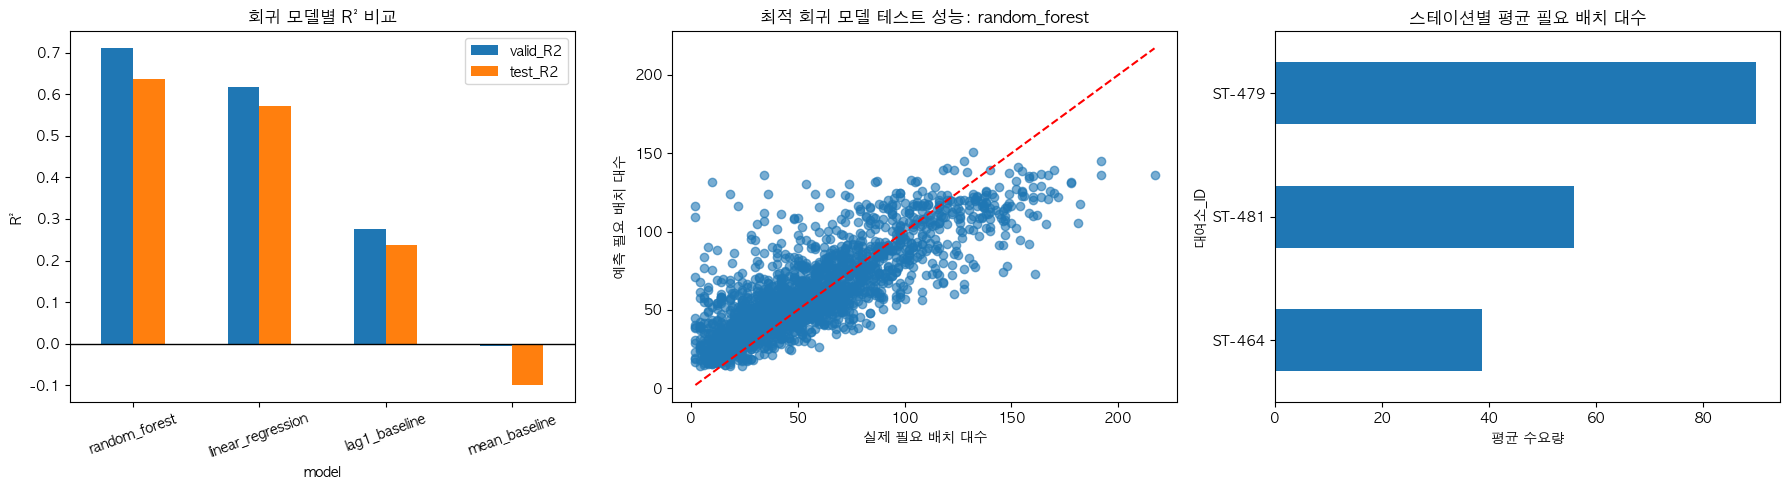

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_df = regression_result_df.set_index('model')[['valid_R2', 'test_R2']]
plot_df.plot(kind='bar', ax=axes[0], title='회귀 모델별 R² 비교')
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_ylabel('R²')
axes[0].tick_params(axis='x', rotation=20)

best_pred = reg_predictions[best_reg_model_name]['test']
axes[1].scatter(y_test_reg, best_pred, alpha=0.6)
min_val = min(y_test_reg.min(), best_pred.min())
max_val = max(y_test_reg.max(), best_pred.max())
axes[1].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')
axes[1].set_title(f'최적 회귀 모델 테스트 성능: {best_reg_model_name}')
axes[1].set_xlabel('실제 필요 배치 대수')
axes[1].set_ylabel('예측 필요 배치 대수')

station_summary = season_model_df.groupby('대여소_ID')['필요_배치대수_proxy'].mean().sort_values()
station_summary.plot(kind='barh', ax=axes[2], title='스테이션별 평균 필요 배치 대수')
axes[2].set_xlabel('평균 수요량')

plt.tight_layout()
plt.show()


## 5. 방문 시각별 이용 가능성 분류용 데이터 만들기

이번 분류 모델은 다음 질문에 답하기 위한 것입니다.

- "사용자가 특정 시각에 이 스테이션에 방문하면 따릉이를 이용할 수 있을까?"

하지만 실제 재고 데이터가 없기 때문에, 분류 타깃은 아래와 같이 `proxy`로 정의합니다.

- `이용가능_proxy = 해당 스테이션-해당 시각(1시간 구간)에 실제 출발 이용이 1건 이상 있었으면 1, 아니면 0`

의미:
- 실제로 그 시간대에 출발 기록이 있었다면, 적어도 역사적으로는 그 시각에 자전거 이용이 가능했던 흔적이 있다고 해석합니다.
- 이것은 엄밀한 재고 availability는 아니고, **관측된 이용 가능성의 대체 지표**입니다.

모델에는 `방문 시각` 자체가 피처로 들어갑니다.
- 사용자가 몇 시에 방문하는지를 입력하면,
- 그 시간대에 이용 가능성이 높은지 예측할 수 있게 합니다.


In [ ]:
def build_hourly_grid(raw_df, weather_df, year_label):
    start_hour = raw_df['기준_일시'].min().floor('h')
    end_hour = raw_df['기준_일시'].max().floor('h')
    hour_range = pd.date_range(start_hour, end_hour, freq='h')

    grid = pd.MultiIndex.from_product(
        [TARGET_STATIONS, hour_range],
        names=['대여소_ID', '방문_일시'],
    ).to_frame(index=False)

    hourly_counts = (
        raw_df.assign(방문_일시=raw_df['기준_일시'].dt.floor('h'))
        .groupby(['시작_대여소_ID', '방문_일시'], as_index=False)['전체_건수']
        .sum()
        .rename(columns={'시작_대여소_ID': '대여소_ID', '전체_건수': '해당시간_출발건수'})
    )

    result = grid.merge(hourly_counts, on=['대여소_ID', '방문_일시'], how='left')
    result['해당시간_출발건수'] = result['해당시간_출발건수'].fillna(0)
    result['이용가능_proxy'] = (result['해당시간_출발건수'] > 0).astype(int)

    result['방문_요일'] = result['방문_일시'].dt.dayofweek
    result['방문_요일_sin'] = np.sin(2 * np.pi * result['방문_요일'] / 7)
    result['방문_요일_cos'] = np.cos(2 * np.pi * result['방문_요일'] / 7)
    result['방문_시'] = result['방문_일시'].dt.hour
    result['방문_분'] = result['방문_일시'].dt.minute
    result['방문_시_sin'] = np.sin(2 * np.pi * result['방문_시'] / 24)
    result['방문_시_cos'] = np.cos(2 * np.pi * result['방문_시'] / 24)
    result['주말_여부'] = (result['방문_요일'] >= 5).astype(int)
    result['공휴일_여부'] = result['방문_일시'].dt.normalize().isin(KOREA_HOLIDAYS).astype(int)
    result['주말_공휴일_여부'] = ((result['주말_여부'] == 1) | (result['공휴일_여부'] == 1)).astype(int)
    result = add_season_columns(result.rename(columns={'방문_일시': '기준_일시'})).rename(columns={'기준_일시': '방문_일시'})

    weather_for_merge = weather_df.rename(columns={'weather_time': '방문_일시'})
    result = result.merge(weather_for_merge, on='방문_일시', how='left')
    result['불쾌지수'] = 0.81 * result['기온'] + 0.01 * result['습도'] * (0.99 * result['기온'] - 14.3) + 46.3
    result['data_split'] = year_label
    return result

class_df_2024 = build_hourly_grid(weather_merged_2024.copy(), weather_2024.copy(), '2024')
class_df_2025 = build_hourly_grid(weather_merged_2025.copy(), weather_2025.copy(), '2025')
classification_df = pd.concat([class_df_2024, class_df_2025], ignore_index=True)

train_cls_df = classification_df[(classification_df['data_split'] == '2024') & (classification_df['방문_일시'] < VALID_START)].copy()
valid_cls_df = classification_df[(classification_df['data_split'] == '2024') & (classification_df['방문_일시'] >= VALID_START)].copy()
test_cls_df = classification_df[classification_df['data_split'] == '2025'].copy()

cls_feature_cols = [
    '대여소_ID', '시즌_라벨', '방문_요일_sin', '방문_요일_cos', '방문_시_sin', '방문_시_cos',
    '주말_여부', '공휴일_여부', '주말_공휴일_여부',
    '평일_출근시즌_여부', '평일_퇴근시즌_여부',
    '기온', '강수량', '적설량', '습도', '불쾌지수'
]
cls_target_col = '이용가능_proxy'

print('train_cls_df:', train_cls_df.shape)
print('valid_cls_df:', valid_cls_df.shape)
print('test_cls_df :', test_cls_df.shape)
display(classification_df.head())


train_cls_df: (19728, 32)
valid_cls_df: (6624, 32)
test_cls_df : (25704, 32)


,대여소_ID,방문_일시,해당시간_출발건수,이용가능_proxy,방문_요일,방문_요일_sin,방문_요일_cos,방문_시,방문_분,방문_시_sin,...,시즌_공휴일여부,시즌_주말공휴일여부,평일_출근시즌_여부,평일_퇴근시즌_여부,기온,강수량,적설량,습도,불쾌지수,data_split
0,ST-464,2024-01-01 00:00:00,2.0,1,0,0.0,1.0,0,0,0.000000,...,0,1,0,0,-2.7,0.0,0.0,92,28.49784,2024
1,ST-464,2024-01-01 01:00:00,0.0,0,0,0.0,1.0,1,0,0.258819,...,0,1,0,0,-1.2,0.0,0.0,87,31.85344,2024
2,ST-464,2024-01-01 02:00:00,2.0,1,0,0.0,1.0,2,0,0.500000,...,0,1,0,0,-1.2,0.0,0.0,88,31.69856,2024
3,ST-464,2024-01-01 03:00:00,2.0,1,0,0.0,1.0,3,0,0.707107,...,0,1,0,0,-1.1,0.0,0.0,88,31.86668,2024
4,ST-464,2024-01-01 04:00:00,0.0,0,0,0.0,1.0,4,0,0.866025,...,1,1,0,0,-1.0,0.0,0.0,87,32.18770,2024


## 6. 방문 시각별 이용 가능성 분류 모델 학습

비교 모델은 3개입니다.

1. `majority_baseline`
   - 학습 데이터에서 더 많은 클래스를 그대로 예측
2. `logistic_regression`
   - 해석 가능한 기본 분류 모델
3. `random_forest_classifier`
   - 비선형 관계를 반영하는 분류 모델

평가 지표는 아래를 같이 봅니다.
- `Accuracy`
- `Precision`
- `Recall`
- `F1`
- `ROC-AUC`

실무적으로는 `Accuracy` 하나만 보면 안 됩니다.
- 이용 가능(1) 비중이 높으면 Accuracy는 쉽게 높아질 수 있습니다.
- 그래서 `Precision`, `Recall`, `F1`, `ROC-AUC`를 함께 확인해야 합니다.


In [ ]:
cls_categorical_cols = ['대여소_ID', '시즌_라벨']
cls_numeric_cols = [col for col in cls_feature_cols if col not in cls_categorical_cols]

cls_preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cls_categorical_cols),
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), cls_numeric_cols),
    ]
)

X_train_cls = train_cls_df[cls_feature_cols]
y_train_cls = train_cls_df[cls_target_col]
X_valid_cls = valid_cls_df[cls_feature_cols]
y_valid_cls = valid_cls_df[cls_target_col]
X_test_cls = test_cls_df[cls_feature_cols]
y_test_cls = test_cls_df[cls_target_col]

majority_class = int(y_train_cls.mode().iloc[0])

cls_models = {
    'majority_baseline': None,
    'logistic_regression': Pipeline([
        ('preprocess', cls_preprocess),
        ('model', LogisticRegression(max_iter=1000)),
    ]),
    'random_forest_classifier': Pipeline([
        ('preprocess', cls_preprocess),
        ('model', RandomForestClassifier(
            n_estimators=300,
            max_depth=10,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1,
        )),
    ]),
}

cls_results = []
cls_predictions = {}

for model_name, model in cls_models.items():
    if model_name == 'majority_baseline':
        valid_pred = np.full(len(y_valid_cls), majority_class)
        test_pred = np.full(len(y_test_cls), majority_class)
        valid_prob = np.full(len(y_valid_cls), y_train_cls.mean())
        test_prob = np.full(len(y_test_cls), y_train_cls.mean())
    else:
        model.fit(X_train_cls, y_train_cls)
        valid_pred = model.predict(X_valid_cls)
        test_pred = model.predict(X_test_cls)
        valid_prob = model.predict_proba(X_valid_cls)[:, 1]
        test_prob = model.predict_proba(X_test_cls)[:, 1]

    cls_predictions[model_name] = {
        'valid_pred': valid_pred,
        'valid_prob': valid_prob,
        'test_pred': test_pred,
        'test_prob': test_prob,
    }

    valid_metrics = cls_metrics(y_valid_cls, valid_pred, valid_prob)
    test_metrics = cls_metrics(y_test_cls, test_pred, test_prob)

    cls_results.append({
        'model': model_name,
        'valid_Accuracy': valid_metrics['Accuracy'],
        'valid_Precision': valid_metrics['Precision'],
        'valid_Recall': valid_metrics['Recall'],
        'valid_F1': valid_metrics['F1'],
        'valid_ROC_AUC': valid_metrics['ROC_AUC'],
        'test_Accuracy': test_metrics['Accuracy'],
        'test_Precision': test_metrics['Precision'],
        'test_Recall': test_metrics['Recall'],
        'test_F1': test_metrics['F1'],
        'test_ROC_AUC': test_metrics['ROC_AUC'],
    })

classification_result_df = pd.DataFrame(cls_results).sort_values('valid_F1', ascending=False).reset_index(drop=True)
display(classification_result_df)

best_cls_model_name = classification_result_df.iloc[0]['model']
print('최적 분류 모델:', best_cls_model_name)


,model,valid_Accuracy,valid_Precision,valid_Recall,valid_F1,valid_ROC_AUC,test_Accuracy,test_Precision,test_Recall,test_F1,test_ROC_AUC
0,random_forest_classifier,0.807367,0.837272,0.927240,0.879962,0.825524,0.781979,0.794834,0.937133,0.860138,0.831674
1,logistic_regression,0.798762,0.808069,0.964909,0.879552,0.798592,0.760504,0.762647,0.965793,0.852282,0.793312
2,majority_baseline,0.761473,0.761473,1.000000,0.864587,0.500000,0.715375,0.715375,1.000000,0.834074,0.500000


최적 분류 모델: random_forest_classifier


## 7. 분류 모델 결과 시각화

이 셀에서는 다음을 확인합니다.
- 모델별 `Valid/Test F1` 비교
- 최적 모델의 혼동행렬
- 방문 시간대별 평균 이용가능 확률

사용자 관점 해석은 이렇게 하면 됩니다.
- 특정 시간대의 예측 확률이 높으면, 그 시간대는 역사적으로 이용 기록이 상대적으로 자주 발생한 시간입니다.
- 다만 이 값은 실제 재고 보장 확률이 아니라, `관측된 이용 가능성 proxy`라는 점을 함께 설명해야 합니다.


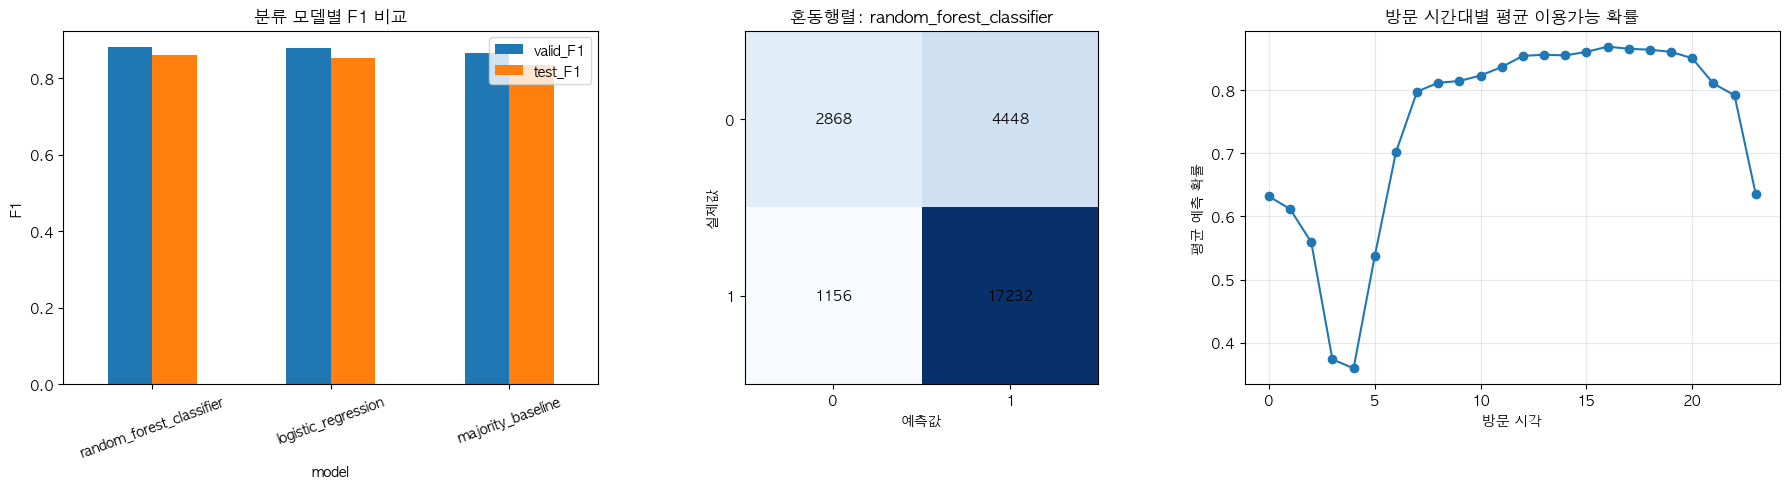

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

classification_result_df.set_index('model')[['valid_F1', 'test_F1']].plot(kind='bar', ax=axes[0], title='분류 모델별 F1 비교')
axes[0].set_ylabel('F1')
axes[0].tick_params(axis='x', rotation=20)

best_cls_pred = cls_predictions[best_cls_model_name]['test_pred']
cm = confusion_matrix(y_test_cls, best_cls_pred)
axes[1].imshow(cm, cmap='Blues')
axes[1].set_title(f'혼동행렬: {best_cls_model_name}')
axes[1].set_xlabel('예측값')
axes[1].set_ylabel('실제값')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[1].text(j, i, cm[i, j], ha='center', va='center')
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])

visit_hour_prob = test_cls_df[['방문_일시']].copy()
visit_hour_prob['방문_시'] = test_cls_df['방문_일시'].dt.hour.values
visit_hour_prob['예측확률'] = cls_predictions[best_cls_model_name]['test_prob']
visit_hour_prob.groupby('방문_시')['예측확률'].mean().plot(ax=axes[2], marker='o', title='방문 시간대별 평균 이용가능 확률')
axes[2].set_xlabel('방문 시각')
axes[2].set_ylabel('평균 예측 확률')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 8. 최종 결과 정리

마지막으로 아래 셀은 분석 결과를 표와 문장으로 한 번에 요약합니다.

확인할 내용:
- 어떤 회귀 모델이 `필요 배치 대수 proxy`를 가장 잘 예측했는지
- 어떤 분류 모델이 `방문 시각별 이용 가능성 proxy`를 가장 잘 분류했는지
- `Valid`와 `Test` 점수 차이가 큰지
- 발표할 때 어떤 표현을 써야 하는지

권장 발표 표현:
- `시즌 시작 전 필요 배치 대수 추정 모델`
- `방문 시각별 이용 가능성 추정 모델`
- `실제 재고 데이터가 없어 proxy 기반으로 분석함`
- `2024년으로 학습/검증, 2025년 데이터로 테스트함`


In [ ]:
best_reg_row = regression_result_df.iloc[0]
best_cls_row = classification_result_df.iloc[0]

display(regression_result_df)
display(classification_result_df)

print('--- 회귀 모델 요약 ---')
print(f"최적 모델: {best_reg_row['model']}")
print(f"검증 R²: {best_reg_row['valid_R2']:.4f}, 테스트 R²: {best_reg_row['test_R2']:.4f}")
print(f"검증 MAE: {best_reg_row['valid_MAE']:.4f}, 테스트 MAE: {best_reg_row['test_MAE']:.4f}")

print('--- 분류 모델 요약 ---')
print(f"최적 모델: {best_cls_row['model']}")
print(f"검증 F1: {best_cls_row['valid_F1']:.4f}, 테스트 F1: {best_cls_row['test_F1']:.4f}")
print(f"검증 ROC-AUC: {best_cls_row['valid_ROC_AUC']:.4f}, 테스트 ROC-AUC: {best_cls_row['test_ROC_AUC']:.4f}")

print('--- 해석 가이드 ---')
print('1. 회귀 R²가 높을수록, 시즌 시작 전에 몇 대를 배치해야 하는지 더 잘 설명합니다.')
print('2. 분류 F1과 ROC-AUC가 높을수록, 사용자가 특정 시각에 방문했을 때 이용 가능성을 더 잘 구분합니다.')
print('3. 테스트 점수가 검증 점수와 크게 다르지 않으면 2025년 데이터에도 비교적 안정적으로 일반화된 것입니다.')
print('4. 실제 재고 데이터가 없으므로 결과는 운영 의사결정을 위한 proxy 결과로 해석해야 합니다.')


,model,valid_MAE,valid_RMSE,valid_R2,test_MAE,test_RMSE,test_R2
0,random_forest,14.880801,19.511960,0.710161,15.907770,21.631053,0.635348
1,linear_regression,15.372875,22.437128,0.616743,17.425492,23.456388,0.571209
2,lag1_baseline,24.042202,30.852029,0.275359,23.031500,31.278328,0.237551
3,mean_baseline,29.001793,36.321490,-0.004344,31.340746,37.553265,-0.099054


,model,valid_Accuracy,valid_Precision,valid_Recall,valid_F1,valid_ROC_AUC,test_Accuracy,test_Precision,test_Recall,test_F1,test_ROC_AUC
0,random_forest_classifier,0.807367,0.837272,0.927240,0.879962,0.825524,0.781979,0.794834,0.937133,0.860138,0.831674
1,logistic_regression,0.798762,0.808069,0.964909,0.879552,0.798592,0.760504,0.762647,0.965793,0.852282,0.793312
2,majority_baseline,0.761473,0.761473,1.000000,0.864587,0.500000,0.715375,0.715375,1.000000,0.834074,0.500000


--- 회귀 모델 요약 ---
최적 모델: random_forest
검증 R²: 0.7102, 테스트 R²: 0.6353
검증 MAE: 14.8808, 테스트 MAE: 15.9078
--- 분류 모델 요약 ---
최적 모델: random_forest_classifier
검증 F1: 0.8800, 테스트 F1: 0.8601
검증 ROC-AUC: 0.8255, 테스트 ROC-AUC: 0.8317
--- 해석 가이드 ---
1. 회귀 R²가 높을수록, 시즌 시작 전에 몇 대를 배치해야 하는지 더 잘 설명합니다.
2. 분류 F1과 ROC-AUC가 높을수록, 사용자가 특정 시각에 방문했을 때 이용 가능성을 더 잘 구분합니다.
3. 테스트 점수가 검증 점수와 크게 다르지 않으면 2025년 데이터에도 비교적 안정적으로 일반화된 것입니다.
4. 실제 재고 데이터가 없으므로 결과는 운영 의사결정을 위한 proxy 결과로 해석해야 합니다.


## 9. 시계열 Rolling Validation으로 검증 구조 보완

단일 기간으로 `train / valid`를 한 번만 나누면 다음 문제가 생길 수 있습니다.

- 특정 계절의 날씨가 `valid`에 과도하게 몰릴 수 있음
- 한 시점의 우연한 패턴에 점수가 크게 좌우될 수 있음
- 2024년 내부 일반화 성능을 충분히 보기 어려움

그래서 이 단계에서는 `rolling validation`을 사용합니다.

검증 구간:
- Fold 1: Train `2024-01 ~ 2024-06`, Valid `2024-07 ~ 2024-08`
- Fold 2: Train `2024-01 ~ 2024-08`, Valid `2024-09 ~ 2024-10`
- Fold 3: Train `2024-01 ~ 2024-10`, Valid `2024-11 ~ 2024-12`

이 구조의 장점:
- 미래 예측 형태를 유지함
- 계절성과 날씨 변동을 여러 구간에서 검증할 수 있음
- 랜덤 분할보다 정보 누설 위험이 작음

최종 평가는 아래처럼 봅니다.
- `Rolling CV 평균 성능`: 2024 내부 검증
- `2025 Test 성능`: 완전한 미래 연도 테스트


In [ ]:
from sklearn.base import clone

rolling_folds = [
    {
        'name': 'fold_1',
        'train_end': pd.Timestamp('2024-07-01 00:00:00'),
        'valid_start': pd.Timestamp('2024-07-01 00:00:00'),
        'valid_end': pd.Timestamp('2024-09-01 00:00:00'),
    },
    {
        'name': 'fold_2',
        'train_end': pd.Timestamp('2024-09-01 00:00:00'),
        'valid_start': pd.Timestamp('2024-09-01 00:00:00'),
        'valid_end': pd.Timestamp('2024-11-01 00:00:00'),
    },
    {
        'name': 'fold_3',
        'train_end': pd.Timestamp('2024-11-01 00:00:00'),
        'valid_start': pd.Timestamp('2024-11-01 00:00:00'),
        'valid_end': pd.Timestamp('2025-01-01 00:00:00'),
    },
]

rolling_fold_df = pd.DataFrame(rolling_folds)
display(rolling_fold_df)


,name,train_end,valid_start,valid_end
0,fold_1,2024-07-01,2024-07-01,2024-09-01
1,fold_2,2024-09-01,2024-09-01,2024-11-01
2,fold_3,2024-11-01,2024-11-01,2025-01-01


## 10. 회귀 모델 Rolling Validation

회귀 모델은 기존과 동일하게 비교하되, 각 모델을 3개 fold에서 반복 평가합니다.

비교 모델:
- `mean_baseline`
- `lag1_baseline`
- `linear_regression`
- `random_forest`

평가 방식:
- 각 fold의 `MAE`, `RMSE`, `R²`
- fold 평균값 계산
- 평균 `R²`가 가장 높은 모델을 선택
- 선택된 모델을 2024 전체로 다시 학습한 뒤 2025 테스트셋 평가


In [ ]:
reg_fold_rows = []

for fold in rolling_folds:
    fold_train = season_model_df[
        (season_model_df['data_split'] == '2024') &
        (season_model_df['시즌_시작일시'] < fold['train_end'])
    ].copy()
    fold_valid = season_model_df[
        (season_model_df['data_split'] == '2024') &
        (season_model_df['시즌_시작일시'] >= fold['valid_start']) &
        (season_model_df['시즌_시작일시'] < fold['valid_end'])
    ].copy()

    X_fold_train = fold_train[reg_feature_cols]
    y_fold_train = fold_train[reg_target_col]
    X_fold_valid = fold_valid[reg_feature_cols]
    y_fold_valid = fold_valid[reg_target_col]
    fold_mean = y_fold_train.mean()

    for model_name, model in reg_models.items():
        if model_name == 'mean_baseline':
            fold_pred = np.full(len(y_fold_valid), fold_mean)
        elif model_name == 'lag1_baseline':
            fold_pred = X_fold_valid['lag_1'].to_numpy()
        else:
            fitted_model = clone(model)
            fitted_model.fit(X_fold_train, y_fold_train)
            fold_pred = fitted_model.predict(X_fold_valid)

        metrics = reg_metrics(y_fold_valid, fold_pred)
        reg_fold_rows.append({
            'fold': fold['name'],
            'model': model_name,
            'MAE': metrics['MAE'],
            'RMSE': metrics['RMSE'],
            'R2': metrics['R2'],
        })

rolling_regression_folds_df = pd.DataFrame(reg_fold_rows)
rolling_regression_summary_df = (
    rolling_regression_folds_df.groupby('model', as_index=False)
    .agg(avg_MAE=('MAE', 'mean'), avg_RMSE=('RMSE', 'mean'), avg_R2=('R2', 'mean'))
    .sort_values('avg_R2', ascending=False)
    .reset_index(drop=True)
)

display(rolling_regression_folds_df)
display(rolling_regression_summary_df)

best_rolling_reg_model_name = rolling_regression_summary_df.iloc[0]['model']
print('Rolling 기준 최적 회귀 모델:', best_rolling_reg_model_name)

full_train_reg_df = season_model_df[season_model_df['data_split'] == '2024'].copy()
X_full_train_reg = full_train_reg_df[reg_feature_cols]
y_full_train_reg = full_train_reg_df[reg_target_col]

if best_rolling_reg_model_name == 'mean_baseline':
    final_reg_test_pred = np.full(len(y_test_reg), y_full_train_reg.mean())
elif best_rolling_reg_model_name == 'lag1_baseline':
    final_reg_test_pred = X_test_reg['lag_1'].to_numpy()
else:
    final_reg_model = clone(reg_models[best_rolling_reg_model_name])
    final_reg_model.fit(X_full_train_reg, y_full_train_reg)
    final_reg_test_pred = final_reg_model.predict(X_test_reg)

rolling_regression_test_metrics = pd.DataFrame([reg_metrics(y_test_reg, final_reg_test_pred)])
display(rolling_regression_test_metrics)


,fold,model,MAE,RMSE,R2
0,fold_1,mean_baseline,24.177491,30.531351,-0.011276
1,fold_1,lag1_baseline,20.566860,27.762542,0.163827
2,fold_1,linear_regression,18.293788,23.522272,0.399744
3,fold_1,random_forest,16.828587,22.485857,0.451475
4,fold_2,mean_baseline,29.669219,39.682134,-0.222567
5,fold_2,lag1_baseline,23.382514,30.587954,0.273587
6,fold_2,linear_regression,18.895840,24.814799,0.521916
7,fold_2,random_forest,17.062392,22.561576,0.604796
8,fold_3,mean_baseline,29.395999,34.676252,-0.221784
9,fold_3,lag1_baseline,22.481894,28.692151,0.163518


,model,avg_MAE,avg_RMSE,avg_R2
0,random_forest,15.602629,20.514620,0.593254
1,linear_regression,16.741980,22.743704,0.506507
2,lag1_baseline,22.143756,29.014216,0.200311
3,mean_baseline,27.747570,34.963246,-0.151876


Rolling 기준 최적 회귀 모델: random_forest


,MAE,RMSE,R2
0,15.23843,20.824752,0.662026


## 11. 분류 모델 Rolling Validation

분류 모델도 같은 방식으로 3개 fold에서 반복 평가합니다.

비교 모델:
- `majority_baseline`
- `logistic_regression`
- `random_forest_classifier`

평가 방식:
- 각 fold의 `Accuracy`, `Precision`, `Recall`, `F1`, `ROC-AUC`
- fold 평균 `F1`를 중심으로 비교
- 최적 모델을 2024 전체로 다시 학습한 뒤 2025 테스트셋 평가


In [ ]:
cls_fold_rows = []

for fold in rolling_folds:
    fold_train = classification_df[
        (classification_df['data_split'] == '2024') &
        (classification_df['방문_일시'] < fold['train_end'])
    ].copy()
    fold_valid = classification_df[
        (classification_df['data_split'] == '2024') &
        (classification_df['방문_일시'] >= fold['valid_start']) &
        (classification_df['방문_일시'] < fold['valid_end'])
    ].copy()

    X_fold_train = fold_train[cls_feature_cols]
    y_fold_train = fold_train[cls_target_col]
    X_fold_valid = fold_valid[cls_feature_cols]
    y_fold_valid = fold_valid[cls_target_col]
    fold_majority_class = int(y_fold_train.mode().iloc[0])

    for model_name, model in cls_models.items():
        if model_name == 'majority_baseline':
            fold_pred = np.full(len(y_fold_valid), fold_majority_class)
            fold_prob = np.full(len(y_fold_valid), y_fold_train.mean())
        else:
            fitted_model = clone(model)
            fitted_model.fit(X_fold_train, y_fold_train)
            fold_pred = fitted_model.predict(X_fold_valid)
            fold_prob = fitted_model.predict_proba(X_fold_valid)[:, 1]

        metrics = cls_metrics(y_fold_valid, fold_pred, fold_prob)
        cls_fold_rows.append({
            'fold': fold['name'],
            'model': model_name,
            'Accuracy': metrics['Accuracy'],
            'Precision': metrics['Precision'],
            'Recall': metrics['Recall'],
            'F1': metrics['F1'],
            'ROC_AUC': metrics['ROC_AUC'],
        })

rolling_classification_folds_df = pd.DataFrame(cls_fold_rows)
rolling_classification_summary_df = (
    rolling_classification_folds_df.groupby('model', as_index=False)
    .agg(
        avg_Accuracy=('Accuracy', 'mean'),
        avg_Precision=('Precision', 'mean'),
        avg_Recall=('Recall', 'mean'),
        avg_F1=('F1', 'mean'),
        avg_ROC_AUC=('ROC_AUC', 'mean'),
    )
    .sort_values('avg_F1', ascending=False)
    .reset_index(drop=True)
)

display(rolling_classification_folds_df)
display(rolling_classification_summary_df)

best_rolling_cls_model_name = rolling_classification_summary_df.iloc[0]['model']
print('Rolling 기준 최적 분류 모델:', best_rolling_cls_model_name)

full_train_cls_df = classification_df[classification_df['data_split'] == '2024'].copy()
X_full_train_cls = full_train_cls_df[cls_feature_cols]
y_full_train_cls = full_train_cls_df[cls_target_col]

if best_rolling_cls_model_name == 'majority_baseline':
    final_cls_test_pred = np.full(len(y_test_cls), int(y_full_train_cls.mode().iloc[0]))
    final_cls_test_prob = np.full(len(y_test_cls), y_full_train_cls.mean())
else:
    final_cls_model = clone(cls_models[best_rolling_cls_model_name])
    final_cls_model.fit(X_full_train_cls, y_full_train_cls)
    final_cls_test_pred = final_cls_model.predict(X_test_cls)
    final_cls_test_prob = final_cls_model.predict_proba(X_test_cls)[:, 1]

rolling_classification_test_metrics = pd.DataFrame([cls_metrics(y_test_cls, final_cls_test_pred, final_cls_test_prob)])
display(rolling_classification_test_metrics)


,fold,model,Accuracy,Precision,Recall,F1,ROC_AUC
0,fold_1,majority_baseline,0.735663,0.735663,1.000000,0.847703,0.500000
1,fold_1,logistic_regression,0.763889,0.784149,0.936967,0.853774,0.733372
2,fold_1,random_forest_classifier,0.779346,0.800209,0.933009,0.861521,0.740311
3,fold_2,majority_baseline,0.837432,0.837432,1.000000,0.911524,0.500000
4,fold_2,logistic_regression,0.850182,0.866327,0.970908,0.915641,0.813544
5,fold_2,random_forest_classifier,0.850182,0.894050,0.931485,0.912383,0.842910
6,fold_3,majority_baseline,0.721767,0.721767,1.000000,0.838403,0.500000
7,fold_3,logistic_regression,0.771403,0.774734,0.963407,0.858830,0.784893
8,fold_3,random_forest_classifier,0.785519,0.806212,0.925237,0.861633,0.816033


,model,avg_Accuracy,avg_Precision,avg_Recall,avg_F1,avg_ROC_AUC
0,random_forest_classifier,0.805016,0.833490,0.929910,0.878513,0.799751
1,logistic_regression,0.795158,0.808403,0.957094,0.876082,0.777270
2,majority_baseline,0.764954,0.764954,1.000000,0.865876,0.500000


Rolling 기준 최적 분류 모델: random_forest_classifier


,Accuracy,Precision,Recall,F1,ROC_AUC
0,0.789877,0.801001,0.939743,0.864843,0.841909


## 12. Rolling Validation 최종 해석

이제는 단일 시점 검증보다 아래 결과를 더 우선해서 해석하면 됩니다.

- `rolling_regression_summary_df`: 2024 내부 회귀 평균 성능
- `rolling_regression_test_metrics`: 2025 회귀 최종 성능
- `rolling_classification_summary_df`: 2024 내부 분류 평균 성능
- `rolling_classification_test_metrics`: 2025 분류 최종 성능

해석 원칙:
- 2024 내부 평균 성능이 안정적인지 먼저 확인
- 그 다음 2025 테스트에서 얼마나 유지되는지 확인
- rolling 평균과 2025 테스트 차이가 작을수록 일반화가 더 안정적이라고 볼 수 있음


In [ ]:
print('--- Rolling 회귀 요약 ---')
display(rolling_regression_summary_df)
print('2025 test metrics')
display(rolling_regression_test_metrics)

print('--- Rolling 분류 요약 ---')
display(rolling_classification_summary_df)
print('2025 test metrics')
display(rolling_classification_test_metrics)

print('회귀 최종 모델:', best_rolling_reg_model_name)
print('분류 최종 모델:', best_rolling_cls_model_name)


--- Rolling 회귀 요약 ---


,model,avg_MAE,avg_RMSE,avg_R2
0,random_forest,15.602629,20.514620,0.593254
1,linear_regression,16.741980,22.743704,0.506507
2,lag1_baseline,22.143756,29.014216,0.200311
3,mean_baseline,27.747570,34.963246,-0.151876


2025 test metrics


,MAE,RMSE,R2
0,15.23843,20.824752,0.662026


--- Rolling 분류 요약 ---


,model,avg_Accuracy,avg_Precision,avg_Recall,avg_F1,avg_ROC_AUC
0,random_forest_classifier,0.805016,0.833490,0.929910,0.878513,0.799751
1,logistic_regression,0.795158,0.808403,0.957094,0.876082,0.777270
2,majority_baseline,0.764954,0.764954,1.000000,0.865876,0.500000


2025 test metrics


,Accuracy,Precision,Recall,F1,ROC_AUC
0,0.789877,0.801001,0.939743,0.864843,0.841909


회귀 최종 모델: random_forest
분류 최종 모델: random_forest_classifier


## 13. 상관관계 분석과 피처 적합성 판단

모델을 설명력 있게 해석하려면 단순히 점수만 보는 것이 아니라, 어떤 피처가 실제로 타깃과 관련이 있는지도 확인해야 합니다.

이 단계에서는 세 가지를 봅니다.
- 회귀 타깃(`필요_배치대수_proxy`)과 수치형 피처의 상관관계
- 분류 타깃(`이용가능_proxy`)과 수치형 피처의 상관관계
- 랜덤포레스트 기반 피처 중요도

해석 원칙:
- 상관계수는 선형 관계의 강도를 보여줍니다.
- 절대값이 크다고 바로 채택하는 것이 아니라, 예측 시점에 알 수 있는 값인지 먼저 확인해야 합니다.
- 최종적으로는 `상관관계 + 모델 중요도 + 정보 누설 여부`를 같이 보고 피처를 선택하는 것이 맞습니다.


In [ ]:
reg_corr_cols = [
    '필요_배치대수_proxy', '시즌_요일_sin', '시즌_요일_cos',
    '주말_여부', '공휴일_여부', '주말_공휴일_여부',
    '평일_출근시즌_여부', '평일_퇴근시즌_여부',
    '기온', '강수량', '적설량', '습도', '불쾌지수',
    'lag_1', 'lag_2', 'lag_3', 'rolling_mean_3'
]
reg_corr_df = season_model_df[reg_corr_cols].corr(numeric_only=True)['필요_배치대수_proxy'].sort_values(key=lambda s: s.abs(), ascending=False)
reg_corr_df = reg_corr_df.drop(labels=['필요_배치대수_proxy'])

cls_corr_cols = [
    '이용가능_proxy', '방문_요일_sin', '방문_요일_cos', '방문_시_sin', '방문_시_cos',
    '주말_여부', '공휴일_여부', '주말_공휴일_여부',
    '평일_출근시즌_여부', '평일_퇴근시즌_여부',
    '기온', '강수량', '적설량', '습도', '불쾌지수'
]
cls_corr_df = classification_df[cls_corr_cols].corr(numeric_only=True)['이용가능_proxy'].sort_values(key=lambda s: s.abs(), ascending=False)
cls_corr_df = cls_corr_df.drop(labels=['이용가능_proxy'])

print('[회귀 타깃 상관관계 상위 피처]')
display(reg_corr_df.to_frame('corr_with_need_proxy'))

print('[분류 타깃 상관관계 상위 피처]')
display(cls_corr_df.to_frame('corr_with_availability_proxy'))


[회귀 타깃 상관관계 상위 피처]


,corr_with_need_proxy
rolling_mean_3,0.711046
lag_2,0.691670
lag_1,0.659625
lag_3,0.532879
기온,0.295347
불쾌지수,0.270577
평일_출근시즌_여부,0.162594
강수량,-0.137843
주말_공휴일_여부,-0.136140
주말_여부,-0.121236


[분류 타깃 상관관계 상위 피처]


,corr_with_availability_proxy
방문_시_cos,-0.253696
방문_시_sin,-0.230083
습도,-0.219071
기온,0.184811
불쾌지수,0.183955
강수량,-0.148605
적설량,-0.081606
평일_출근시즌_여부,0.053530
공휴일_여부,-0.032259
평일_퇴근시즌_여부,-0.026482


In [ ]:
from sklearn.inspection import permutation_importance

reg_rf_pipe = clone(reg_models['random_forest'])
reg_rf_pipe.fit(X_train_reg, y_train_reg)
reg_feature_names = reg_rf_pipe.named_steps['preprocess'].get_feature_names_out()
reg_importance = pd.DataFrame({
    'feature': reg_feature_names,
    'importance': reg_rf_pipe.named_steps['model'].feature_importances_,
}).sort_values('importance', ascending=False).reset_index(drop=True)

cls_rf_pipe = clone(cls_models['random_forest_classifier'])
cls_rf_pipe.fit(X_train_cls, y_train_cls)
cls_feature_names = cls_rf_pipe.named_steps['preprocess'].get_feature_names_out()
cls_importance = pd.DataFrame({
    'feature': cls_feature_names,
    'importance': cls_rf_pipe.named_steps['model'].feature_importances_,
}).sort_values('importance', ascending=False).reset_index(drop=True)

print('[회귀 랜덤포레스트 중요도]')
display(reg_importance.head(20))
print('[분류 랜덤포레스트 중요도]')
display(cls_importance.head(20))


[회귀 랜덤포레스트 중요도]


,feature,importance
0,num__lag_1,0.461609
1,num__rolling_mean_3,0.171815
2,num__lag_2,0.067831
3,num__강수량,0.051150
4,num__불쾌지수,0.039181
5,num__기온,0.038012
6,num__습도,0.037313
7,num__lag_3,0.031188
8,cat__대여소_ID_ST-479,0.021863
9,num__평일_출근시즌_여부,0.016050


[분류 랜덤포레스트 중요도]


,feature,importance
0,num__방문_시_cos,0.175108
1,num__방문_시_sin,0.153310
2,num__습도,0.125763
3,num__불쾌지수,0.124300
4,num__기온,0.116613
5,num__강수량,0.102195
6,num__방문_요일_sin,0.031275
7,cat__대여소_ID_ST-464,0.026528
8,cat__대여소_ID_ST-479,0.021764
9,num__방문_요일_cos,0.019452


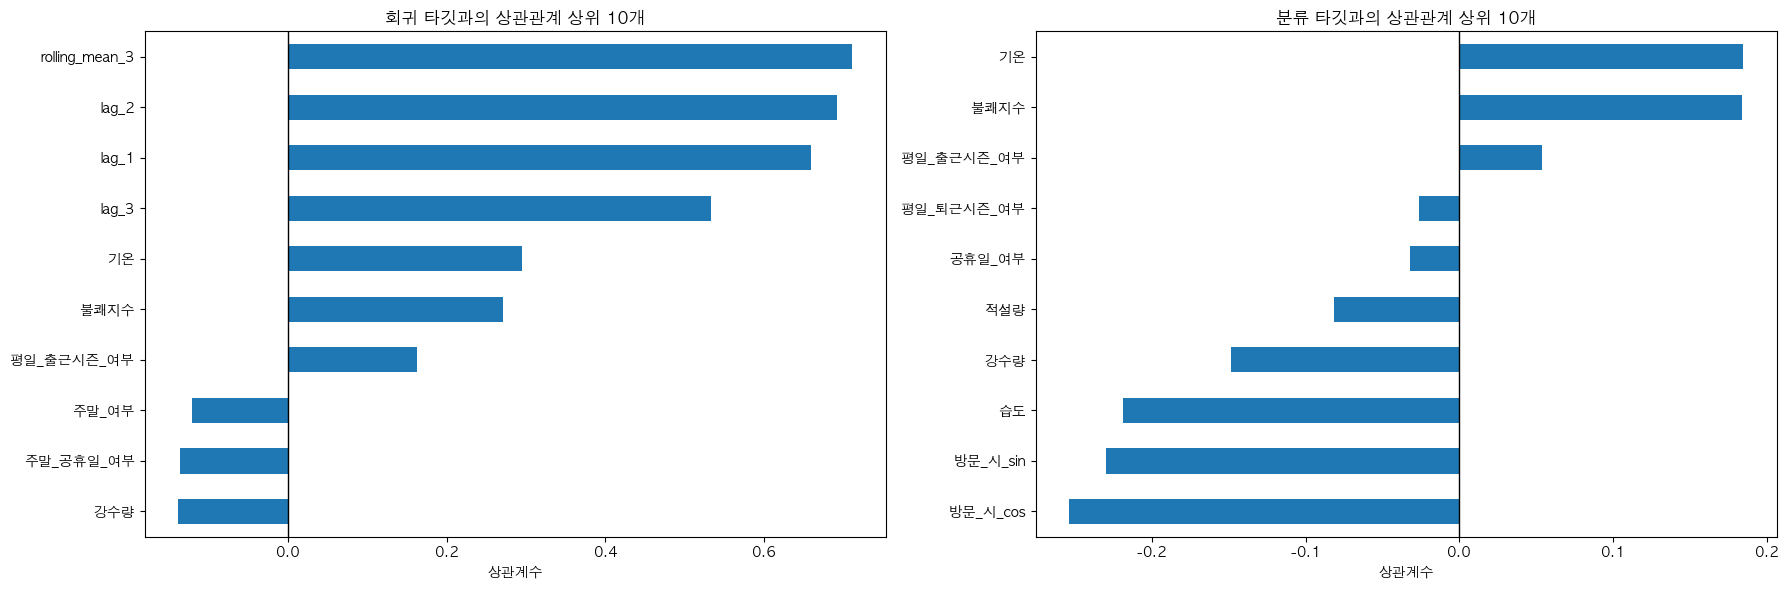

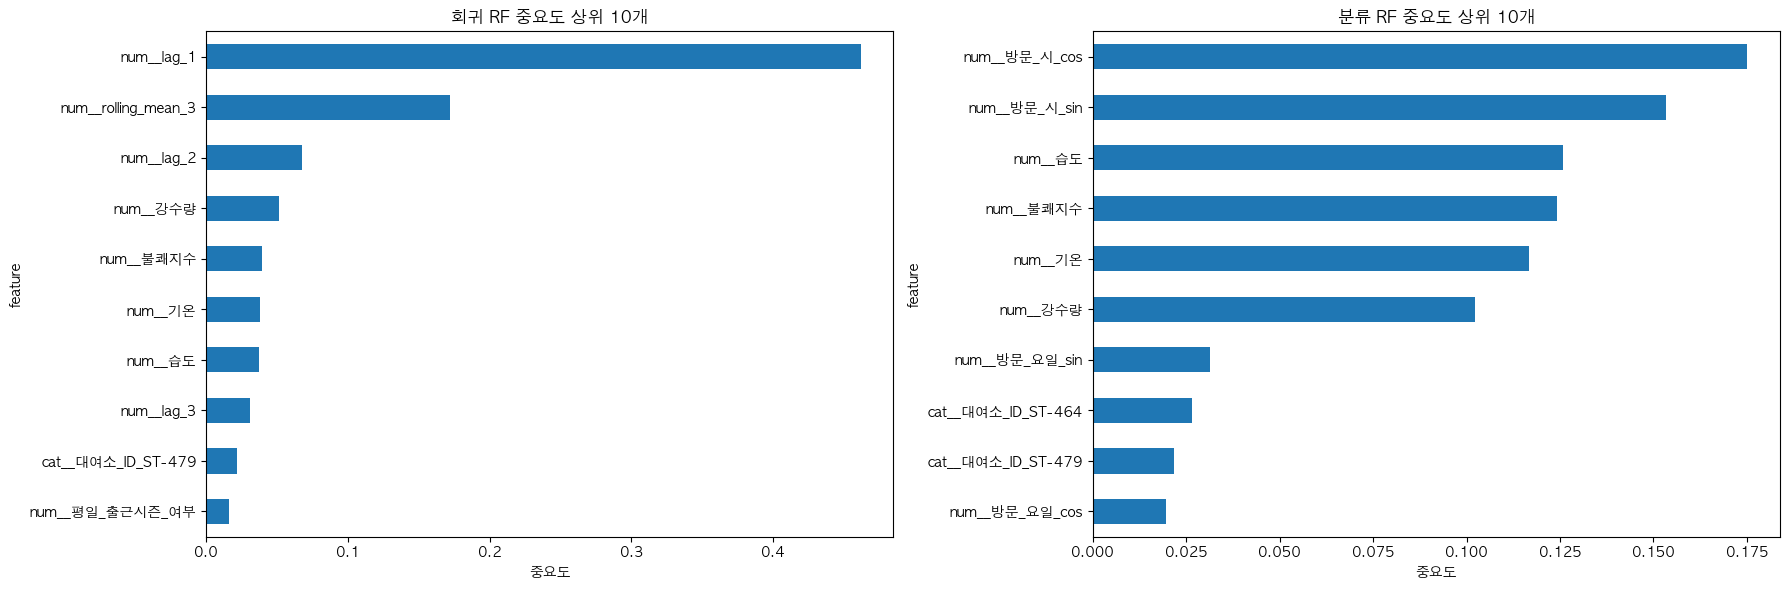

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

reg_corr_df.head(10).sort_values().plot(kind='barh', ax=axes[0], title='회귀 타깃과의 상관관계 상위 10개')
axes[0].set_xlabel('상관계수')
axes[0].axvline(0, color='black', linewidth=1)

cls_corr_df.head(10).sort_values().plot(kind='barh', ax=axes[1], title='분류 타깃과의 상관관계 상위 10개')
axes[1].set_xlabel('상관계수')
axes[1].axvline(0, color='black', linewidth=1)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
reg_importance.head(10).sort_values('importance').plot(kind='barh', x='feature', y='importance', ax=axes[0], legend=False, title='회귀 RF 중요도 상위 10개')
axes[0].set_xlabel('중요도')

cls_importance.head(10).sort_values('importance').plot(kind='barh', x='feature', y='importance', ax=axes[1], legend=False, title='분류 RF 중요도 상위 10개')
axes[1].set_xlabel('중요도')

plt.tight_layout()
plt.show()


## 14. 어떤 피처가 가장 적합한지 판단하는 기준

최종적으로 적합한 피처는 아래 기준으로 판단합니다.

1. 예측 시점 이전에 알 수 있어야 함
- 현재 시즌의 결과값이면 제외
- 미래 날씨나 미래 수요도 제외

2. 타깃과 통계적 관련성이 있어야 함
- 상관계수 절대값이 너무 낮으면 설명력이 약할 수 있음
- 다만 비선형 관계는 상관계수만으로 놓칠 수 있음

3. 모델 중요도에서도 반복적으로 상위에 나와야 함
- 회귀와 분류에서 모두 상위권이면 안정적인 피처일 가능성이 큼

4. 해석 가능성이 있어야 함
- 운영자가 실제로 이해하고 사용할 수 있어야 함

보통 우선순위가 높은 피처는 아래일 가능성이 큽니다.
- `lag_1`, `lag_2`, `lag_3`, `rolling_mean_3`
- `시작_대여소_ID`
- `시즌_라벨`
- `방문_시_sin`, `방문_시_cos`
- `주말/공휴일 여부`
- `기온`, `강수량`, `불쾌지수`

반대로 조심할 피처는 아래입니다.
- 실제로는 예측 시점에 알 수 없는 값
- 특정 기간에만 우연히 강한 상관을 보이는 값
- 운영적으로 설명하기 어려운 값


In [ ]:
recommended_reg_features = []
for feature in reg_importance['feature'].head(12):
    if not any(bad in feature for bad in ['필요_배치대수_proxy']):
        recommended_reg_features.append(feature)

recommended_cls_features = []
for feature in cls_importance['feature'].head(12):
    if not any(bad in feature for bad in ['이용가능_proxy']):
        recommended_cls_features.append(feature)

print('[회귀 추천 피처 후보]')
for feature in recommended_reg_features:
    print('-', feature)

print('[분류 추천 피처 후보]')
for feature in recommended_cls_features:
    print('-', feature)


[회귀 추천 피처 후보]
- num__lag_1
- num__rolling_mean_3
- num__lag_2
- num__강수량
- num__불쾌지수
- num__기온
- num__습도
- num__lag_3
- cat__대여소_ID_ST-479
- num__평일_출근시즌_여부
- num__시즌_요일_sin
- cat__대여소_ID_ST-464
[분류 추천 피처 후보]
- num__방문_시_cos
- num__방문_시_sin
- num__습도
- num__불쾌지수
- num__기온
- num__강수량
- num__방문_요일_sin
- cat__대여소_ID_ST-464
- cat__대여소_ID_ST-479
- num__방문_요일_cos
- cat__시즌_라벨_오후 시즌
- cat__시즌_라벨_오전 시즌


## 15. Permutation Importance로 피처 영향 재확인

- `feature_importances_`는 트리 모델 내부 분할 기준에 의존합니다.
- `permutation importance`는 특정 피처를 섞었을 때 점수가 얼마나 떨어지는지를 보기 때문에, 실제 예측 성능 기여도를 해석하기에 더 직관적입니다.
- 여기서는 검증셋 기준으로 회귀는 `R²`, 분류는 `F1` 점수 하락을 이용해 permutation importance를 계산합니다.


[회귀 permutation importance]


,feature,importance_mean,importance_std
0,lag_1,0.289514,0.019147
1,rolling_mean_3,0.119122,0.012082
2,lag_2,0.078410,0.010948
3,대여소_ID,0.064009,0.006464
4,평일_출근시즌_여부,0.048125,0.004843
5,강수량,0.034290,0.007419
6,기온,0.029918,0.005417
7,시즌_라벨,0.017399,0.001817
8,습도,0.011350,0.001791
9,불쾌지수,0.009311,0.003445


[분류 permutation importance]


,feature,importance_mean,importance_std
0,방문_시_cos,0.053725,0.002343
1,방문_시_sin,0.030523,0.001966
2,대여소_ID,0.008593,0.001092
3,불쾌지수,0.003620,0.000660
4,기온,0.002899,0.000704
5,시즌_라벨,0.002299,0.000973
6,강수량,0.002151,0.000469
7,평일_출근시즌_여부,0.000816,0.000551
8,방문_요일_sin,0.000805,0.000382
9,습도,0.000703,0.000661


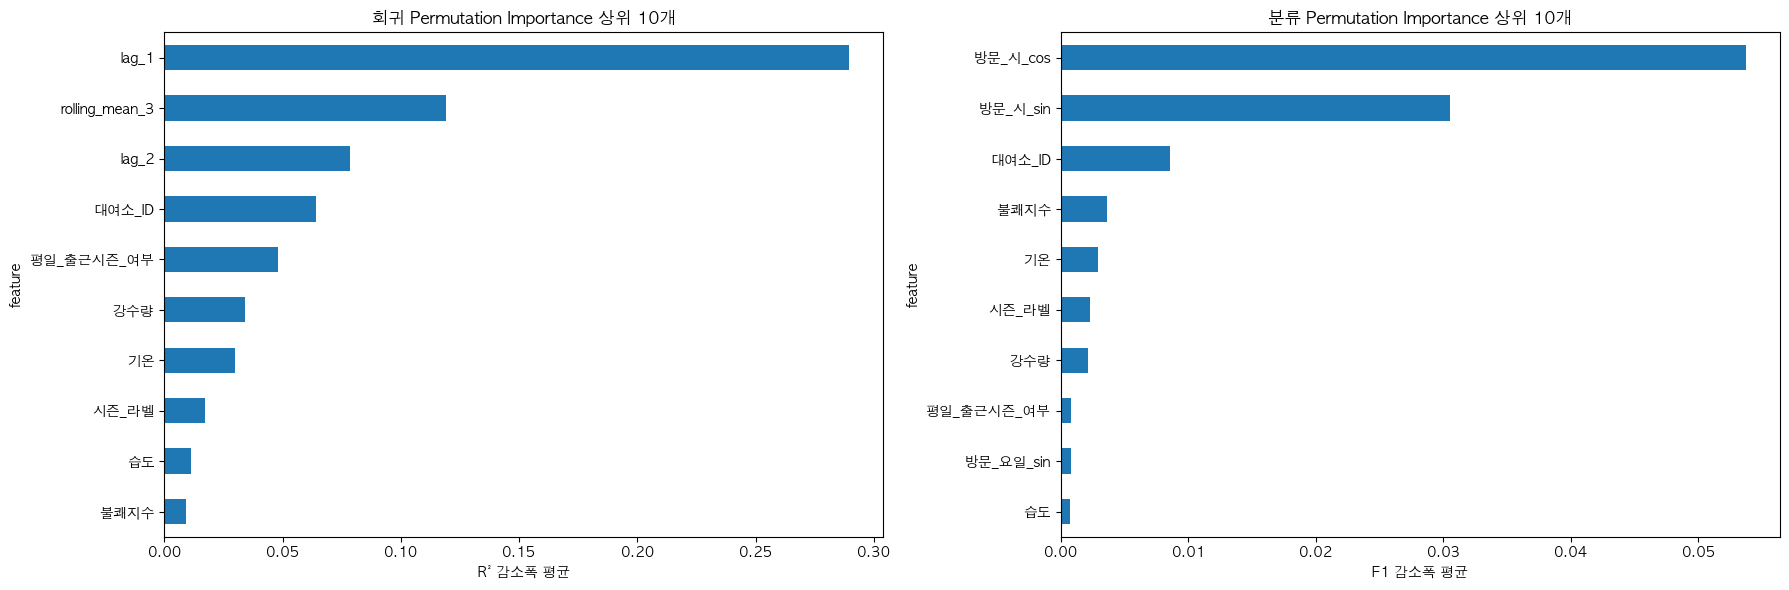

In [ ]:
best_reg_for_perm = clone(reg_models['random_forest'])
best_reg_for_perm.fit(X_train_reg, y_train_reg)
reg_perm = permutation_importance(
    best_reg_for_perm,
    X_valid_reg,
    y_valid_reg,
    n_repeats=10,
    random_state=42,
    scoring='r2',
    n_jobs=-1,
)
reg_perm_df = pd.DataFrame({
    'feature': X_valid_reg.columns,
    'importance_mean': reg_perm.importances_mean,
    'importance_std': reg_perm.importances_std,
}).sort_values('importance_mean', ascending=False).reset_index(drop=True)

best_cls_for_perm = clone(cls_models['random_forest_classifier'])
best_cls_for_perm.fit(X_train_cls, y_train_cls)
cls_perm = permutation_importance(
    best_cls_for_perm,
    X_valid_cls,
    y_valid_cls,
    n_repeats=10,
    random_state=42,
    scoring='f1',
    n_jobs=-1,
)
cls_perm_df = pd.DataFrame({
    'feature': X_valid_cls.columns,
    'importance_mean': cls_perm.importances_mean,
    'importance_std': cls_perm.importances_std,
}).sort_values('importance_mean', ascending=False).reset_index(drop=True)

print('[회귀 permutation importance]')
display(reg_perm_df.head(15))
print('[분류 permutation importance]')
display(cls_perm_df.head(15))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
reg_perm_df.head(10).sort_values('importance_mean').plot(
    kind='barh', x='feature', y='importance_mean', ax=axes[0], legend=False, title='회귀 Permutation Importance 상위 10개'
)
axes[0].set_xlabel('R² 감소폭 평균')

cls_perm_df.head(10).sort_values('importance_mean').plot(
    kind='barh', x='feature', y='importance_mean', ax=axes[1], legend=False, title='분류 Permutation Importance 상위 10개'
)
axes[1].set_xlabel('F1 감소폭 평균')

plt.tight_layout()
plt.show()


## 16. 재고 분석 기준으로 다시 시작

지금 목표는 아래 두 가지입니다.
- 시간대별로 해당 스테이션에 몇 대의 따릉이가 있어야 하는가
- 오전 4시 / 오후 4시마다 몇 대를 채워 넣어야 하는가

이 문제는 기존의 `출발 건수 예측`과 다릅니다. 재고 분석을 하려면 반드시 아래 정보가 모두 필요합니다.
- 해당 스테이션에서 **출발한 건수**
- 해당 스테이션으로 **도착한 건수**

따라서 기존처럼 `시작_대여소_ID`만 필터링하면 안 되고,
`시작 또는 종료가 3개 스테이션인 모든 이용 기록`을 다시 사용해야 합니다.

이번 섹션에서 새로 만드는 핵심 타깃은 다음과 같습니다.
- `시즌별 최소 필요 초기재고`: 그 시즌이 시작될 때 최소 몇 대가 있어야 시즌 중 재고가 음수가 되지 않는가
- `시간대별 추정 재고`: 시즌 시작 시 최소 필요 초기재고를 채워넣었다고 가정했을 때, 각 시간대 예상 재고가 몇 대인가

이 타깃은 실제 재고 센서가 없어도 `출발(-), 도착(+) 흐름`으로 계산할 수 있는 가장 타당한 운영 지표입니다.


In [ ]:
inventory_source_2024 = df_2024[
    df_2024['시작_대여소_ID'].isin(TARGET_STATIONS) | df_2024['종료_대여소_ID'].isin(TARGET_STATIONS)
].copy()
inventory_source_2025 = df_2025[
    df_2025['시작_대여소_ID'].isin(TARGET_STATIONS) | df_2025['종료_대여소_ID'].isin(TARGET_STATIONS)
].copy()

inventory_common_cols = sorted(set(inventory_source_2024.columns) & set(inventory_source_2025.columns))
inventory_source_2024 = inventory_source_2024[inventory_common_cols].copy()
inventory_source_2025 = inventory_source_2025[inventory_common_cols].copy()

inventory_source_2024 = classify_usage_rows(inventory_source_2024)
inventory_source_2025 = classify_usage_rows(inventory_source_2025)

inventory_clean_2024 = inventory_source_2024[inventory_source_2024['이용데이터_상태'] == '정상 이용'].copy()
inventory_clean_2025 = inventory_source_2025[inventory_source_2025['이용데이터_상태'] == '정상 이용'].copy()

print('[재고 분석용 2024 shape]', inventory_clean_2024.shape)
print('[재고 분석용 2025 shape]', inventory_clean_2025.shape)
print('[2024 시작/종료 포함 건수]')
print('출발 포함:', inventory_clean_2024['시작_대여소_ID'].isin(TARGET_STATIONS).sum())
print('도착 포함:', inventory_clean_2024['종료_대여소_ID'].isin(TARGET_STATIONS).sum())
print('[2025 시작/종료 포함 건수]')
print('출발 포함:', inventory_clean_2025['시작_대여소_ID'].isin(TARGET_STATIONS).sum())
print('도착 포함:', inventory_clean_2025['종료_대여소_ID'].isin(TARGET_STATIONS).sum())


[재고 분석용 2024 shape] (248081, 13)
[재고 분석용 2025 shape] (224999, 13)
[2024 시작/종료 포함 건수]
출발 포함: 135238
도착 포함: 133028
[2025 시작/종료 포함 건수]
출발 포함: 113238
도착 포함: 129100


## 17. 출발/도착 이벤트 테이블 만들기

각 이용 기록은 재고 관점에서 두 개의 이벤트로 바뀝니다.

- 출발 시점: 재고 `-전체_건수`
- 도착 시점: 재고 `+전체_건수`

시간 계산 규칙:
- `집계_기준 = 출발시간`이면
  - 출발 시각 = 원본 기준 시각
  - 도착 시각 = 출발 시각 + 전체 이용 분
- `집계_기준 = 도착시간`이면
  - 도착 시각 = 원본 기준 시각
  - 출발 시각 = 도착 시각 - 전체 이용 분

이렇게 만들면 스테이션별 순유입/순유출 흐름을 시간순으로 계산할 수 있습니다.


In [ ]:
def build_trip_datetimes(df):
    result = df.copy()
    result['기준_날짜_dt'] = pd.to_datetime(result['기준_날짜'].astype(str), format='%Y%m%d', errors='coerce')
    result['기준_시간대_str'] = (
        pd.to_numeric(result['기준_시간대'], errors='coerce')
        .fillna(0)
        .astype(int)
        .astype(str)
        .str.zfill(4)
    )
    result['원본_기준_일시'] = pd.to_datetime(
        result['기준_날짜_dt'].dt.strftime('%Y-%m-%d') + ' ' + result['기준_시간대_str'],
        format='%Y-%m-%d %H%M',
        errors='coerce'
    )
    result['전체_이용_분_num'] = pd.to_numeric(result['전체_이용_분'], errors='coerce')
    result['전체_건수_num'] = pd.to_numeric(result['전체_건수'], errors='coerce').fillna(0)

    departure_mask = result['집계_기준'].astype(str) == '출발시간'
    arrival_mask = result['집계_기준'].astype(str) == '도착시간'

    result['출발_일시'] = pd.NaT
    result['도착_일시'] = pd.NaT
    result.loc[departure_mask, '출발_일시'] = result.loc[departure_mask, '원본_기준_일시']
    result.loc[departure_mask, '도착_일시'] = (
        result.loc[departure_mask, '원본_기준_일시'] + pd.to_timedelta(result.loc[departure_mask, '전체_이용_분_num'], unit='m')
    )
    result.loc[arrival_mask, '도착_일시'] = result.loc[arrival_mask, '원본_기준_일시']
    result.loc[arrival_mask, '출발_일시'] = (
        result.loc[arrival_mask, '원본_기준_일시'] - pd.to_timedelta(result.loc[arrival_mask, '전체_이용_분_num'], unit='m')
    )
    return result


def build_station_events(df, year_label):
    trips = build_trip_datetimes(df)

    departures = trips[trips['시작_대여소_ID'].isin(TARGET_STATIONS)].copy()
    departures = departures[['시작_대여소_ID', '출발_일시', '전체_건수_num']].rename(
        columns={'시작_대여소_ID': '대여소_ID', '출발_일시': '이벤트_일시', '전체_건수_num': '변화량_절대값'}
    )
    departures['이벤트유형'] = '출발'
    departures['재고변화'] = -departures['변화량_절대값']

    arrivals = trips[trips['종료_대여소_ID'].isin(TARGET_STATIONS)].copy()
    arrivals = arrivals[['종료_대여소_ID', '도착_일시', '전체_건수_num']].rename(
        columns={'종료_대여소_ID': '대여소_ID', '도착_일시': '이벤트_일시', '전체_건수_num': '변화량_절대값'}
    )
    arrivals['이벤트유형'] = '도착'
    arrivals['재고변화'] = arrivals['변화량_절대값']

    events = pd.concat([departures, arrivals], ignore_index=True)
    events = events.dropna(subset=['이벤트_일시']).copy()
    events['이벤트_일시'] = pd.to_datetime(events['이벤트_일시'])
    events['data_split'] = year_label
    events = events.sort_values(['대여소_ID', '이벤트_일시', '이벤트유형']).reset_index(drop=True)
    return events

inventory_events_2024 = build_station_events(inventory_clean_2024, '2024')
inventory_events_2025 = build_station_events(inventory_clean_2025, '2025')
inventory_events = pd.concat([inventory_events_2024, inventory_events_2025], ignore_index=True)

print('[inventory_events_2024]', inventory_events_2024.shape)
display(inventory_events_2024.head())
print('[inventory_events_2025]', inventory_events_2025.shape)
display(inventory_events_2025.head())


[inventory_events_2024] (268266, 6)


,대여소_ID,이벤트_일시,변화량_절대값,이벤트유형,재고변화,data_split
0,ST-464,2024-01-01 00:45:00,1.0,출발,-1.0,2024
1,ST-464,2024-01-01 00:46:00,1.0,출발,-1.0,2024
2,ST-464,2024-01-01 01:10:00,1.0,도착,1.0,2024
3,ST-464,2024-01-01 01:23:00,1.0,도착,1.0,2024
4,ST-464,2024-01-01 01:25:00,1.0,도착,1.0,2024


[inventory_events_2025] (242338, 6)


,대여소_ID,이벤트_일시,변화량_절대값,이벤트유형,재고변화,data_split
0,ST-464,2025-01-09 00:09:00,1,출발,-1,2025
1,ST-464,2025-01-09 00:10:00,1,출발,-1,2025
2,ST-464,2025-01-09 01:40:00,1,도착,1,2025
3,ST-464,2025-01-09 01:40:00,1,도착,1,2025
4,ST-464,2025-01-09 08:20:00,1,도착,1,2025


## 18. 시즌별 최소 필요 초기재고 계산

이제 각 스테이션-시즌마다 재고 흐름을 계산할 수 있습니다.

계산 방식:
1. 시즌 내부 이벤트를 시간순으로 정렬
2. `재고변화`를 누적합하여 순재고 흐름 계산
3. 누적합의 최솟값이 음수라면, 그 절댓값만큼은 시즌 시작 전에 반드시 채워야 함

수식으로 쓰면:
- `필요_초기재고 = max(0, -min(cumsum(재고변화)))`

이 값은 오전 4시 또는 오후 4시에 최소 몇 대를 채워 넣어야 해당 시즌 동안 재고가 음수가 되지 않는지를 의미합니다.

그리고 시즌 시작 시 이만큼 채워 넣었다고 가정하면,
각 시간대의 추정 재고는 아래처럼 계산할 수 있습니다.
- `추정재고 = 필요_초기재고 + cumsum(재고변화)`


In [ ]:
inventory_events = add_season_columns(inventory_events.rename(columns={'이벤트_일시': '기준_일시'})).rename(columns={'기준_일시': '이벤트_일시'})

season_event_flow = (
    inventory_events.groupby(['data_split', '대여소_ID', '시즌_시작일시', '시즌_라벨', '이벤트_일시'], as_index=False)['재고변화']
    .sum()
    .sort_values(['data_split', '대여소_ID', '시즌_시작일시', '이벤트_일시'])
)

season_event_flow['누적순재고흐름'] = season_event_flow.groupby(['data_split', '대여소_ID', '시즌_시작일시'])['재고변화'].cumsum()

season_inventory_target = (
    season_event_flow.groupby(['data_split', '대여소_ID', '시즌_시작일시', '시즌_라벨'], as_index=False)
    .agg(
        시즌순유입합=('재고변화', 'sum'),
        시즌최저누적흐름=('누적순재고흐름', 'min'),
        시즌최대누적흐름=('누적순재고흐름', 'max'),
        시즌이벤트수=('재고변화', 'size'),
    )
)
season_inventory_target['필요_초기재고'] = (-season_inventory_target['시즌최저누적흐름']).clip(lower=0)

print('[시즌별 필요 초기재고]')
display(season_inventory_target.head(10))
print('[스테이션별 평균 필요 초기재고]')
display(season_inventory_target.groupby('대여소_ID')['필요_초기재고'].mean().sort_values(ascending=False))


[시즌별 필요 초기재고]


,data_split,대여소_ID,시즌_시작일시,시즌_라벨,시즌순유입합,시즌최저누적흐름,시즌최대누적흐름,시즌이벤트수,필요_초기재고
0,2024,ST-464,2023-12-31 16:00:00,오후 시즌,-1.0,-2.0,3.0,8,2.0
1,2024,ST-464,2024-01-01 04:00:00,오전 시즌,6.0,0.0,6.0,14,-0.0
2,2024,ST-464,2024-01-01 16:00:00,오후 시즌,-8.0,-8.0,-1.0,24,8.0
3,2024,ST-464,2024-01-02 04:00:00,오전 시즌,4.0,-2.0,6.0,26,2.0
4,2024,ST-464,2024-01-02 16:00:00,오후 시즌,-4.0,-6.0,2.0,45,6.0
5,2024,ST-464,2024-01-03 04:00:00,오전 시즌,10.0,1.0,10.0,23,0.0
6,2024,ST-464,2024-01-03 16:00:00,오후 시즌,-16.0,-16.0,1.0,55,16.0
7,2024,ST-464,2024-01-04 04:00:00,오전 시즌,10.0,-2.0,12.0,29,2.0
8,2024,ST-464,2024-01-04 16:00:00,오후 시즌,-18.0,-20.0,-1.0,41,20.0
9,2024,ST-464,2024-01-05 04:00:00,오전 시즌,4.0,-2.0,4.0,24,2.0


[스테이션별 평균 필요 초기재고]


대여소_ID
ST-479    25.939588
ST-481    13.617852
ST-464     9.544313
Name: 필요_초기재고, dtype: float64

## 19. 시간대별 추정 재고 테이블 만들기

시즌 시작 시 `필요_초기재고`를 채워 넣었다고 가정하면, 각 시간대 추정 재고를 계산할 수 있습니다.

이 테이블은 앞으로 두 가지 분석의 기반이 됩니다.
- `몇 시에 방문했을 때 자전거를 탈 수 있는가`
- `시간대별로 예상 재고가 몇 대인가`

이 단계에서는 이벤트 단위 재고를 시간 단위로 집계하여 `시간대별 추정 재고`를 만듭니다.


In [ ]:
hourly_event_flow = season_event_flow.copy()
hourly_event_flow['시간단위'] = hourly_event_flow['이벤트_일시'].dt.floor('h')

hourly_event_flow = (
    hourly_event_flow.groupby(['data_split', '대여소_ID', '시즌_시작일시', '시즌_라벨', '시간단위'], as_index=False)['재고변화']
    .sum()
    .sort_values(['data_split', '대여소_ID', '시즌_시작일시', '시간단위'])
)

hourly_inventory = hourly_event_flow.merge(
    season_inventory_target[['data_split', '대여소_ID', '시즌_시작일시', '필요_초기재고']],
    on=['data_split', '대여소_ID', '시즌_시작일시'],
    how='left'
)
hourly_inventory['시간대_누적순재고흐름'] = hourly_inventory.groupby(['data_split', '대여소_ID', '시즌_시작일시'])['재고변화'].cumsum()
hourly_inventory['추정재고'] = hourly_inventory['필요_초기재고'] + hourly_inventory['시간대_누적순재고흐름']
hourly_inventory['이용가능여부'] = (hourly_inventory['추정재고'] > 0).astype(int)

print('[시간대별 추정 재고]')
display(hourly_inventory.head(20))


[시간대별 추정 재고]


,data_split,대여소_ID,시즌_시작일시,시즌_라벨,시간단위,재고변화,필요_초기재고,시간대_누적순재고흐름,추정재고,이용가능여부
0,2024,ST-464,2023-12-31 16:00:00,오후 시즌,2024-01-01 00:00:00,-2.0,2.0,-2.0,0.0,0
1,2024,ST-464,2023-12-31 16:00:00,오후 시즌,2024-01-01 01:00:00,5.0,2.0,3.0,5.0,1
2,2024,ST-464,2023-12-31 16:00:00,오후 시즌,2024-01-01 02:00:00,-2.0,2.0,1.0,3.0,1
3,2024,ST-464,2023-12-31 16:00:00,오후 시즌,2024-01-01 03:00:00,-2.0,2.0,-1.0,1.0,1
4,2024,ST-464,2024-01-01 04:00:00,오전 시즌,2024-01-01 09:00:00,2.0,-0.0,2.0,2.0,1
5,2024,ST-464,2024-01-01 04:00:00,오전 시즌,2024-01-01 10:00:00,-2.0,-0.0,0.0,0.0,0
6,2024,ST-464,2024-01-01 04:00:00,오전 시즌,2024-01-01 14:00:00,0.0,-0.0,0.0,0.0,0
7,2024,ST-464,2024-01-01 04:00:00,오전 시즌,2024-01-01 15:00:00,6.0,-0.0,6.0,6.0,1
8,2024,ST-464,2024-01-01 16:00:00,오후 시즌,2024-01-01 16:00:00,-4.0,8.0,-4.0,4.0,1
9,2024,ST-464,2024-01-01 16:00:00,오후 시즌,2024-01-01 17:00:00,-4.0,8.0,-8.0,0.0,0


## 20. 필요 초기재고 예측용 회귀 데이터셋 만들기

이제 타깃은 `필요_초기재고`입니다.

피처는 시즌 시작 전에 알 수 있는 값만 사용합니다.
- 대여소 ID
- 시즌 라벨
- 요일/주말/공휴일 정보
- 시즌 시작 시점 날씨
- 직전 시즌 필요 초기재고(`lag_1`, `lag_2`, `lag_3`)
- 직전 3시즌 평균 필요 초기재고

즉, 이번 회귀 모델은 `다음 오전 4시 또는 오후 4시에 몇 대를 채워 넣어야 하는가`를 직접 예측하는 모델입니다.


In [ ]:
inventory_reg_df = season_inventory_target.copy()

for frame in [inventory_reg_df]:
    frame['시즌_요일'] = frame['시즌_시작일시'].dt.dayofweek
    frame['시즌_요일_sin'] = np.sin(2 * np.pi * frame['시즌_요일'] / 7)
    frame['시즌_요일_cos'] = np.cos(2 * np.pi * frame['시즌_요일'] / 7)
    frame['주말_여부'] = (frame['시즌_요일'] >= 5).astype(int)
    frame['공휴일_여부'] = frame['시즌_시작일시'].dt.normalize().isin(KOREA_HOLIDAYS).astype(int)
    frame['주말_공휴일_여부'] = ((frame['주말_여부'] == 1) | (frame['공휴일_여부'] == 1)).astype(int)
    frame['평일_출근시즌_여부'] = ((frame['시즌_라벨'] == '오전 시즌') & (frame['주말_공휴일_여부'] == 0)).astype(int)
    frame['평일_퇴근시즌_여부'] = ((frame['시즌_라벨'] == '오후 시즌') & (frame['주말_공휴일_여부'] == 0)).astype(int)

season_weather_2024_for_inventory = weather_2024.rename(columns={'weather_time': '시즌_시작일시'})
season_weather_2025_for_inventory = weather_2025.rename(columns={'weather_time': '시즌_시작일시'})
season_weather_inventory = pd.concat([
    season_weather_2024_for_inventory.assign(data_split='2024'),
    season_weather_2025_for_inventory.assign(data_split='2025'),
], ignore_index=True)

inventory_reg_df = inventory_reg_df.merge(
    season_weather_inventory,
    on=['data_split', '시즌_시작일시'],
    how='left'
)
inventory_reg_df['불쾌지수'] = 0.81 * inventory_reg_df['기온'] + 0.01 * inventory_reg_df['습도'] * (0.99 * inventory_reg_df['기온'] - 14.3) + 46.3

inventory_reg_df = inventory_reg_df.sort_values(['대여소_ID', '시즌_시작일시']).reset_index(drop=True)
inventory_reg_df['lag_1'] = inventory_reg_df.groupby('대여소_ID')['필요_초기재고'].shift(1)
inventory_reg_df['lag_2'] = inventory_reg_df.groupby('대여소_ID')['필요_초기재고'].shift(2)
inventory_reg_df['lag_3'] = inventory_reg_df.groupby('대여소_ID')['필요_초기재고'].shift(3)
inventory_reg_df['rolling_mean_3'] = (
    inventory_reg_df.groupby('대여소_ID')['필요_초기재고']
    .transform(lambda s: s.shift(1).rolling(3).mean())
)
inventory_reg_df = inventory_reg_df.dropna(subset=['lag_1', 'lag_2', 'lag_3', 'rolling_mean_3']).copy()

train_inventory_reg_df = inventory_reg_df[(inventory_reg_df['data_split'] == '2024') & (inventory_reg_df['시즌_시작일시'] < VALID_START)].copy()
valid_inventory_reg_df = inventory_reg_df[(inventory_reg_df['data_split'] == '2024') & (inventory_reg_df['시즌_시작일시'] >= VALID_START)].copy()
test_inventory_reg_df = inventory_reg_df[inventory_reg_df['data_split'] == '2025'].copy()

inventory_reg_feature_cols = [
    '대여소_ID', '시즌_라벨', '시즌_요일_sin', '시즌_요일_cos',
    '주말_여부', '공휴일_여부', '주말_공휴일_여부',
    '평일_출근시즌_여부', '평일_퇴근시즌_여부',
    '기온', '강수량', '적설량', '습도', '불쾌지수',
    'lag_1', 'lag_2', 'lag_3', 'rolling_mean_3'
]

print('train_inventory_reg_df:', train_inventory_reg_df.shape)
print('valid_inventory_reg_df:', valid_inventory_reg_df.shape)
print('test_inventory_reg_df :', test_inventory_reg_df.shape)
display(inventory_reg_df.head())


train_inventory_reg_df: (1583, 26)
valid_inventory_reg_df: (548, 26)
test_inventory_reg_df : (2134, 26)


,data_split,대여소_ID,시즌_시작일시,시즌_라벨,시즌순유입합,시즌최저누적흐름,시즌최대누적흐름,시즌이벤트수,필요_초기재고,시즌_요일,...,평일_퇴근시즌_여부,기온,강수량,적설량,습도,불쾌지수,lag_1,lag_2,lag_3,rolling_mean_3
3,2024,ST-464,2024-01-02 04:00:00,오전 시즌,4.0,-2.0,6.0,26,2.0,1,...,0,0.3,0.0,0.0,94.0,33.38018,8.0,-0.0,2.0,3.333333
4,2024,ST-464,2024-01-02 16:00:00,오후 시즌,-4.0,-6.0,2.0,45,6.0,1,...,1,3.7,0.0,0.0,59.0,43.02117,2.0,8.0,-0.0,3.333333
5,2024,ST-464,2024-01-03 04:00:00,오전 시즌,10.0,1.0,10.0,23,0.0,2,...,0,-0.3,0.0,0.0,90.0,32.91970,6.0,2.0,8.0,5.333333
6,2024,ST-464,2024-01-03 16:00:00,오후 시즌,-16.0,-16.0,1.0,55,16.0,2,...,1,2.8,0.0,0.0,75.0,39.92200,0.0,6.0,2.0,2.666667
7,2024,ST-464,2024-01-04 04:00:00,오전 시즌,10.0,-2.0,12.0,29,2.0,3,...,0,-4.6,0.0,0.0,83.0,26.92518,16.0,0.0,6.0,7.333333


## 21. 필요 초기재고 회귀 모델 학습 및 평가

비교 모델은 아래 4개입니다.
- `mean_baseline`
- `lag1_baseline`
- `linear_regression`
- `random_forest`

여기서 가장 중요한 지표는 `R²`입니다.
- `R²`가 높을수록, 4시마다 몇 대를 채워 넣어야 하는지를 더 잘 설명합니다.
- 동시에 `MAE`도 같이 봐야 실제 대수 오차를 해석할 수 있습니다.


In [ ]:
inventory_reg_categorical_cols = ['대여소_ID', '시즌_라벨']
inventory_reg_numeric_cols = [col for col in inventory_reg_feature_cols if col not in inventory_reg_categorical_cols]

inventory_reg_preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), inventory_reg_categorical_cols),
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), inventory_reg_numeric_cols),
    ]
)

X_train_inv_reg = train_inventory_reg_df[inventory_reg_feature_cols]
y_train_inv_reg = train_inventory_reg_df['필요_초기재고']
X_valid_inv_reg = valid_inventory_reg_df[inventory_reg_feature_cols]
y_valid_inv_reg = valid_inventory_reg_df['필요_초기재고']
X_test_inv_reg = test_inventory_reg_df[inventory_reg_feature_cols]
y_test_inv_reg = test_inventory_reg_df['필요_초기재고']

inventory_reg_models = {
    'mean_baseline': None,
    'lag1_baseline': None,
    'linear_regression': Pipeline([
        ('preprocess', inventory_reg_preprocess),
        ('model', LinearRegression()),
    ]),
    'random_forest': Pipeline([
        ('preprocess', inventory_reg_preprocess),
        ('model', RandomForestRegressor(
            n_estimators=300,
            max_depth=10,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1,
        )),
    ]),
}

inventory_reg_results = []
inventory_reg_predictions = {}
train_inv_mean = y_train_inv_reg.mean()

for model_name, model in inventory_reg_models.items():
    if model_name == 'mean_baseline':
        valid_pred = np.full(len(y_valid_inv_reg), train_inv_mean)
        test_pred = np.full(len(y_test_inv_reg), train_inv_mean)
    elif model_name == 'lag1_baseline':
        valid_pred = X_valid_inv_reg['lag_1'].to_numpy()
        test_pred = X_test_inv_reg['lag_1'].to_numpy()
    else:
        model.fit(X_train_inv_reg, y_train_inv_reg)
        valid_pred = model.predict(X_valid_inv_reg)
        test_pred = model.predict(X_test_inv_reg)

    inventory_reg_predictions[model_name] = {'valid': valid_pred, 'test': test_pred}
    valid_metrics = reg_metrics(y_valid_inv_reg, valid_pred)
    test_metrics = reg_metrics(y_test_inv_reg, test_pred)
    inventory_reg_results.append({
        'model': model_name,
        'valid_MAE': valid_metrics['MAE'],
        'valid_RMSE': valid_metrics['RMSE'],
        'valid_R2': valid_metrics['R2'],
        'test_MAE': test_metrics['MAE'],
        'test_RMSE': test_metrics['RMSE'],
        'test_R2': test_metrics['R2'],
    })

inventory_regression_result_df = pd.DataFrame(inventory_reg_results).sort_values('valid_R2', ascending=False).reset_index(drop=True)
best_inventory_reg_model_name = inventory_regression_result_df.iloc[0]['model']
display(inventory_regression_result_df)
print('최적 필요초기재고 회귀 모델:', best_inventory_reg_model_name)


,model,valid_MAE,valid_RMSE,valid_R2,test_MAE,test_RMSE,test_R2
0,random_forest,7.619746,10.458356,0.692697,8.136332,11.292365,0.618122
1,linear_regression,8.159803,11.179845,0.648835,8.931630,12.024460,0.567001
2,mean_baseline,14.867835,18.870824,-0.000510,14.434841,18.656258,-0.042328
3,lag1_baseline,25.844891,31.992101,-1.875580,19.594658,28.769672,-1.478707


최적 필요초기재고 회귀 모델: random_forest


## 22. 필요 초기재고 회귀 결과 시각화

이 셀에서는 회귀 결과를 직관적으로 확인합니다.

- 스테이션별 평균 필요 초기재고
- 모델별 검증/테스트 `R²` 비교
- 최적 모델의 테스트셋 실제값 vs 예측값

해석 포인트:
- 스테이션별 평균 필요 초기재고가 다르면, 대여소별 보충 전략도 달라져야 합니다.
- 실제값과 예측값이 대각선에 가까울수록 모델 설명력이 높습니다.


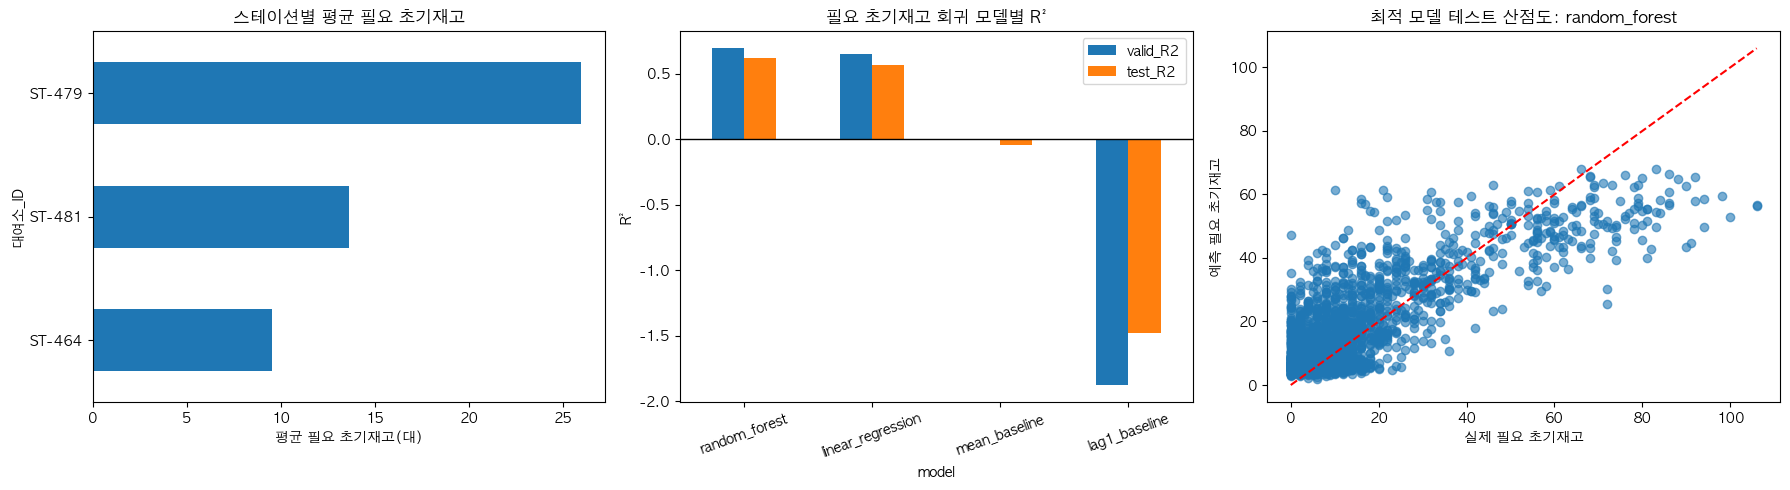

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

station_need_summary = season_inventory_target.groupby('대여소_ID')['필요_초기재고'].mean().sort_values()
station_need_summary.plot(kind='barh', ax=axes[0], title='스테이션별 평균 필요 초기재고')
axes[0].set_xlabel('평균 필요 초기재고(대)')

inventory_regression_result_df.set_index('model')[['valid_R2', 'test_R2']].plot(kind='bar', ax=axes[1], title='필요 초기재고 회귀 모델별 R²')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_ylabel('R²')
axes[1].tick_params(axis='x', rotation=20)

best_inv_test_pred = inventory_reg_predictions[best_inventory_reg_model_name]['test']
axes[2].scatter(y_test_inv_reg, best_inv_test_pred, alpha=0.6)
min_val = min(y_test_inv_reg.min(), best_inv_test_pred.min())
max_val = max(y_test_inv_reg.max(), best_inv_test_pred.max())
axes[2].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')
axes[2].set_title(f'최적 모델 테스트 산점도: {best_inventory_reg_model_name}')
axes[2].set_xlabel('실제 필요 초기재고')
axes[2].set_ylabel('예측 필요 초기재고')

plt.tight_layout()
plt.show()


## 분석 목적 정리

이번 분석의 핵심 목적은 아래와 같다.

`ST-464`, `ST-481`, `ST-479` 3개 스테이션에 대해  
출발(`-`)과 도착(`+`) 흐름을 이용하여  
`오전 4시`, `오후 4시`마다 필요한 최소 배치 대수를 추정하고,  
그 배치량을 기준으로 시간대별 이용 가능성을 분석한다.

---

## 현재 분석 방향이 맞는 이유

기존에는 단순히 출발 수요를 예측하는 방향이었지만,  
실제로 필요한 것은 다음 두 가지이다.

1. `4시마다 몇 대를 채워 넣어야 하는가`
2. `사용자가 몇 시에 방문했을 때 자전거를 탈 수 있는가`

이 질문에 답하려면 단순 출발 건수만 보면 안 되고,  
해당 스테이션에서의 `출발`과 `도착`이 모두 반영되어야 한다.

즉, 재고 분석은 다음 구조로 가는 것이 맞다.

- 출발 이벤트: 재고 감소
- 도착 이벤트: 재고 증가
- 시간순 누적합: 재고 흐름 추정
- 시즌 시작 전 필요 최소 재고 계산
- 그 재고를 기준으로 시간대별 이용 가능 여부 판단

---

## 현재 분석에서 맞는 부분

현재 방향에서 유지해야 하는 핵심은 아래와 같다.

- 2024년 데이터를 train/valid로 사용
- 2025년 데이터를 test로 사용
- `오전 4시`, `오후 4시`를 시즌 시작 시점으로 설정
- `시작 또는 종료가 3개 스테이션인 데이터`를 사용
- 출발/도착 이벤트를 시간순으로 재구성
- 시즌별 `필요_초기재고` 계산
- 시간대별 `추정재고` 계산

---

## 핵심 타깃 정의

### 1. 필요 초기재고
각 시즌 시작 시점(`04:00`, `16:00`)에  
최소 몇 대가 있어야 시즌 중 재고가 음수가 되지 않는지를 의미한다.

수식으로는 다음과 같다.

`필요_초기재고 = max(0, -min(cumsum(재고변화)))`

여기서 재고변화는

- 출발: `-전체_건수`
- 도착: `+전체_건수`

이다.

### 2. 시간대별 추정재고
시즌 시작 시 `필요_초기재고`만큼 채워 넣었다고 가정했을 때  
각 시간대에 스테이션에 몇 대가 남아 있을지를 의미한다.

수식은 다음과 같다.

`추정재고 = 필요_초기재고 + cumsum(재고변화)`

### 3. 이용가능여부
특정 시간대에 `추정재고 > 0`이면 자전거 이용 가능,  
그렇지 않으면 이용 불가능으로 본다.

---

## 이 분석의 올바른 해석

이 분석은 `실제 재고 복원`이 아니다.

이유는 아래와 같다.

- 실제 재고 센서 데이터가 없음
- 실제 보충 이력이 없음
- 시즌 시작 시 실제 몇 대가 있었는지 알 수 없음

따라서 현재 분석은 다음처럼 표현해야 한다.

- `실제 재고 예측`
  - 부정확한 표현
- `출발/도착 흐름 기반 최소 필요 초기재고 추정`
  - 적절한 표현
- `시간대별 이용 가능성 추정`
  - 적절한 표현

즉, 이번 분석은  
`운영 의사결정을 위한 시뮬레이션 기반 추정 분석`이라고 보는 것이 맞다.

---

## 최종적으로 남겨야 할 모델

### 1. 필요 초기재고 회귀 모델
목표:
- 다음 `오전 4시` 또는 `오후 4시`에 몇 대를 채워야 하는지 예측

타깃:
- `필요_초기재고`

### 2. 시간대별 이용가능여부 분류 모델
목표:
- 특정 시간에 방문했을 때 자전거를 탈 수 있는지 예측

타깃:
- `이용가능여부`

---

## 상대적으로 중요도가 낮아진 기존 분석

아래 분석은 현재 목표와 직접 연결성이 약해졌다.

- 시즌 총수요 예측
- 단순 출발 건수 기반 이용가능성 proxy
- 재고 흐름을 반영하지 않은 수요 중심 분류

이유는 현재 핵심 질문이  
`수요가 얼마나 있는가`보다  
`재고를 어떻게 배치해야 하는가`에 더 가깝기 때문이다.

---

## 앞으로의 권장 진행 순서

1. `season_inventory_target` 검증
   - 시즌별 필요 초기재고가 타당하게 계산되는지 확인

2. `hourly_inventory` 검증
   - 시간대별 추정재고와 이용가능여부 확인

3. `필요_초기재고` 회귀 모델 학습
   - 4시 / 16시 보충 필요량 예측

4. `이용가능여부` 분류 모델 학습
   - 시간대별 이용 가능성 예측

5. 결과 시각화 및 보고서 정리
   - 스테이션별 필요 초기재고
   - 시간대별 추정재고
   - 회귀/분류 성능표
   - 한계와 해석 명시

---

## 보고서용 한 줄 요약

본 분석은 3개 스테이션의 출발·도착 흐름을 이용하여  
오전 4시와 오후 4시 기준 최소 필요 배치 대수를 추정하고,  
이를 바탕으로 시간대별 자전거 이용 가능성을 분석하는 것을 목적으로 한다.
